# Lab 03 — Customer Segmentation

Customer segmentation transforms raw transaction data into actionable groups — customers who look alike, spend alike, and respond to similar marketing. A well-chosen segmentation tells the business **who** to target, **how** much to invest, and **what** message to send, without running a separate campaign for every individual.

This notebook builds a complete segmentation pipeline: raw data ingestion, data quality audits, exploratory analysis, multi-algorithm clustering experiments, model selection with diagnostic plots, segment profiling, and deployment-ready model export. Every decision — from scaler choice to cluster count — is justified against competing alternatives so the final answer is transparent, reproducible, and defensible.

### Project Workflow Overview

| Step | Step Name | Description | Python Modules | Saved Outputs |
| ---: | :--- | :--- | :--- | :--- |
| 0 | Define Problem | Frame the business question, dataset overview, and success criteria for segmentation. | — | — |
| 1 | Import Libraries And Setup | Load libraries and local modules, set random seed, check paths. | `sys`, `pathlib`, `pandas`, `matplotlib`, `utils`, `preprocess`, `eda`, `clustering` | — |
| 2 | Load Data And Raw Overview | Load customer dataset, print dimensions, check dtypes and missing values. | `preprocess`, `utils`, `pandas` | `data/processed/metrics/eda_summary.csv` |
| 3 | Data Quality Checks | Filter invalid values, identify outliers (z-score and IQR), and plot boxplots. | `preprocess`, `eda`, `utils` | `data/processed/metrics/preprocessing_report.md`, `data/processed/metrics/missing_values.csv`, `data/processed/metrics/duplicate_summary.csv`, `data/processed/metrics/invalid_value_summary.csv`, `data/processed/metrics/outlier_summary.csv`, `data/processed/customers_clean.csv` |
| 4 | EDA Before Preprocessing | Analyze feature distributions, gender ratios, correlations, and key scatters. | `eda`, `pandas` | `reports/figures/before_process/` |
| 5 | Preprocessing & Scaling | Clean features, scale numeric columns, and generate standard/gender feature sets. | `preprocess`, `utils`, `pandas` | `data/processed/customers_scaled.csv` |
| 6 | Clustering Experiments | Run grid search over KMeans (K=2..10) and Gaussian Mixture Model. | `clustering`, `model_from_scratch`, `pandas` | `data/processed/metrics/clustering_metrics.csv` |
| 7 | Model Selection | Choose the optimal K and model config based on Elbow and Silhouette criteria. | `clustering`, `pandas` | — |
| 8 | Cluster Visualization | Plot scatter plots of clusters and centroids in 2D and 2D PCA projections. | `clustering`, `preprocess`, `utils` | `reports/figures/clustering/`, `data/processed/metrics/cluster_centers.csv` |
| 9 | Segment Profiling | Compile aggregated profiles for each customer segment and label the dataset. | `clustering`, `utils` | `data/processed/metrics/segment_profiles.csv`, `data/processed/clustering_results.csv` |
| 10 | Evaluation Summary | Summarize chosen model details, segment name profiles, and business suggestions. | `pandas` | — |
| 11 | Save Artifacts & Deployment | Save the best model, reload it, and verify predictions on dummy customer data. | `clustering`, `joblib`, `preprocess`, `pandas` | `models/best_cluster_model.joblib` |

### What to expect

By the end of the notebook, you should see **4 to 6 distinct customer segments** with clear behavioral signatures — typically a high-spending loyal group, a frugal conservative group, and a few transitional clusters. A **silhouette score above 0.30** on the final model indicates reasonably separated clusters; below 0.20, the segments blend together and business actions are less decisive. The **elbow plot** for K-Means should show diminishing returns after K=4 or K=5, reinforcing that 5 clusters captures most of the structure without over-fragmenting the customer base.


## Step 0 — Define Problem

Customer segmentation is an **unsupervised learning** problem that groups customers with similar behavior into clusters (segments). The goal is not to optimize a single metric, but to produce groups that are **interpretable** and **actionable** from a business perspective.

The input dataset contains customers of a shopping mall with the following attributes:

| Attribute | Description | Type |
| :--- | :--- | :--- |
| `CustomerID` | Customer identifier | Categorical (not used for clustering) |
| `Gender` | Male / Female | Categorical |
| `Age` | Age in years (18–90) | Numeric |
| `Annual Income (k$)` | Annual income in thousands of USD | Numeric |
| `Spending Score (1–100)` | Spending score assigned by the mall based on behavior | Numeric |

### Business questions to answer

1. How many distinct customer groups exist? (optimal K)
2. What are the defining characteristics of each group? (age, income, spending, gender)
3. Which groups are most valuable / at risk of churn / ripe for upselling?
4. What marketing strategy fits each group?

**Success criteria:** The resulting segments must have clear boundaries in income/spending space (silhouette > 0.30), be large enough to be actionable (> 5% of total customers), and be assignable a semantic label (e.g., "High Income, High Spending") that a business team can immediately understand and act on.


## Step 1 — Imports And Setup

Segmentation results are worthless if they cannot be reproduced — a different random seed, a different scaling library, or a slightly different pipeline can produce entirely different clusters. This step locks down the environment: a **fixed random seed (`42`)**, verified module paths, and a single source of truth for directory structure so every downstream result is deterministic.

The notebook delegates heavy logic to four local modules stored alongside it (`notebooks/`). Keeping preprocessing, EDA, clustering, and utilities in separate `.py` files means each module can be tested and reasoned about in isolation — the notebook itself stays focused on the narrative.

| Module | Responsibility |
| :--- | :--- |
| **`utils`** | Path resolution, directory creation, random seed, table/figure save helpers, config loading |
| **`preprocess`** | CSV loading, column normalization, cleaning, scaling, feature matrix construction |
| **`eda`** | Distributions, boxplots, scatter plots, pairplots, correlation heatmaps |
| **`clustering`** | Grid search for K-Means/GMM, metric computation, model selection, cluster profiling, visualization |

The `importlib.reload()` calls ensure that if you edit a module and re-run the notebook, the changes take effect without restarting the kernel — a small detail that saves significant debugging time.

**Expectation:** After executing this cell, the printed `PROJECT_ROOT` should point to the `lab03/` directory (not `notebooks/`), and all four module paths should resolve inside `notebooks/`. If any module path shows a site-packages location, the notebook is importing a different version and the `sys.path` logic needs attention.


In [16]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

def show_saved_figures(paths):
    for figure_path in paths:
        if figure_path is not None:
            display(Image(filename=str(figure_path)))


import utils
import preprocess
import eda
import clustering

import importlib
importlib.reload(utils)
importlib.reload(preprocess)
importlib.reload(eda)
importlib.reload(clustering)

RANDOM_SEED = 42
utils.set_random_seed(RANDOM_SEED)
paths = utils.ensure_directories(PROJECT_ROOT)
config = utils.load_config(PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("utils:", utils.__file__)
print("preprocess:", preprocess.__file__)
print("eda:", eda.__file__)
print("clustering:", clustering.__file__)

PROJECT_ROOT: /Users/quangmanh/Project/lab03
utils: /Users/quangmanh/Project/lab03/src/utils.py
preprocess: /Users/quangmanh/Project/lab03/src/preprocess.py
eda: /Users/quangmanh/Project/lab03/src/eda.py
clustering: /Users/quangmanh/Project/lab03/src/clustering.py


## Step 2 — Load Data And Raw Overview

Before cleaning, before scaling, before any model — the raw data needs a thorough first look. This step answers the most basic questions that, if wrong, invalidate everything downstream: **how many records, what types, how many gaps, and are there duplicate rows?**

The notebook does not hard-code a file name. Instead, `utils.find_raw_csv()` discovers the first CSV under `data/raw/` matching a configurable glob pattern. This keeps the project flexible when the dataset is renamed or when multiple CSV versions exist — only one needs to be present, and the correct one is selected automatically. Column names are normalized immediately (`customer_id`, `gender`, `age`, `annual_income`, `spending_score`) so all downstream code can assume a consistent schema regardless of the source file's naming conventions.

### Key diagnostic checks

| Check | What to look for | Red flag threshold |
| :--- | :--- | :--- |
| **Shape** | ~15,000 rows × 5 columns for the Mall Customers dataset | < 500 rows: sample too small for stable clustering |
| **Missing values** | Zero across all columns | > 5% missing in any column: imputation strategy needed before clustering |
| **Duplicates** | Zero duplicate rows | > 1% duplicates: investigate data pipeline or consider deduplication vs. they may be legitimate repeat purchases |
| **Data types** | Numeric for age/income/spending, categorical for gender/id | Wrong dtypes (e.g., income as string) will silently break scaling |
| **Descriptive stats** | Sensible ranges: age 18–90, income in thousands, spending 1–100 | Negative values, ages > 120, spending outside 1–100 signal data corruption |

**Expectation:** The output should show a clean rectangular dataset with no type mismatches. If the raw data passes these five checks, preprocessing can proceed safely. If any check fails, the problems must be understood and documented before Step 2 — masking bad data behind aggressive cleaning produces clusters you cannot trust.


In [17]:
raw_path = utils.find_raw_csv(PROJECT_ROOT, config["raw_data_glob"])
raw_df = preprocess.load_csv(raw_path)
normalized_raw = preprocess.normalize_column_names(raw_df)

print("Raw path:", raw_path)
print("Shape:", raw_df.shape)
display(raw_df.head())
display(pd.DataFrame({"column": raw_df.columns, "dtype": raw_df.dtypes.astype(str).values}))
display(raw_df.isna().sum().rename("missing_count").to_frame())
print("Duplicate rows:", int(raw_df.duplicated().sum()))
display(raw_df.describe(include="all").T)

Raw path: /Users/quangmanh/Project/lab03/data/raw/datav2.csv
Shape: (2200, 5)


,Customer ID,Gender,Age,Annual Income,Spending Score
0,1,Male,52,46000,49
1,2,Female,35,99000,83
2,3,Female,40,80000,64
3,4,Male,31,74000,83
4,5,Male,47,53000,42


,column,dtype
0,Customer ID,int64
1,Gender,str
2,Age,int64
3,Annual Income,int64
4,Spending Score,int64


,missing_count
Customer ID,0
Gender,0
Age,0
Annual Income,0
Spending Score,0


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,2200.0,NaN,NaN,NaN,1100.5,635.229617,1.0,550.75,1100.5,1650.25,2200.0
Gender,2200,2,Female,1190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2200.0,NaN,NaN,NaN,38.161818,12.16699,18.0,30.0,37.0,44.0,80.0
Annual Income,2200.0,NaN,NaN,NaN,56142.954545,28410.343334,10000.0,31875.0,52050.0,79525.0,144100.0
Spending Score,2200.0,NaN,NaN,NaN,46.365455,25.129082,1.0,26.0,47.5,65.0,100.0


## Step 3 — Data Quality Checks

Clustering algorithms are **sensitive to scale and outliers**. A single customer with an annual income of $10M can shift cluster centroids and distort the entire segmentation. This step systematically catalogues every data quality issue — missing values, duplicates, invalid ranges, and outliers — before any transformation occurs. The output is a **preprocessing report** that later steps can reference when explaining why a particular record was dropped or why a certain scaler was chosen.

### Quality pipeline

| Stage | Method | What it catches |
| :--- | :--- | :--- |
| **Missing values** | Per-column count and percentage | Gaps that need imputation or row removal |
| **Duplicates** | Exact row comparison | Repeated entries that may inflate cluster sizes |
| **Invalid values** | Range checks: age 0–120, income >= 0, spending 1–100 | Impossible data points (negative income, ages > 150) |
| **Outliers (z-score)** | |z| > 3 per numeric column | Extreme values that pull centroids; z-score assumes normality — useful as a first pass |
| **Outliers (IQR)** | Values outside Q1 – 1.5×IQR and Q3 + 1.5×IQR | Robust detection that does not assume symmetric distributions |

Outliers are **summarized, not removed automatically**. The report quantifies how many values sit outside the expected range so you can decide case-by-case whether to winsorize, drop, or retain them. For income data that is right-skewed (most customers earn moderate amounts, a few earn much more), **IQR-based detection flags more points than z-score** — both are reported so you can compare.

**Expectation:** The boxplots should reveal whether `annual_income` and `spending_score` have strong skew or extreme outliers. If the IQR outlier count exceeds 5% of the dataset, consider using `RobustScaler` in Step 4 to reduce the influence of those points. If z-score and IQR disagree substantially, `RobustScaler` becomes the recommended default because the data likely departs from normality.


In [18]:
clean_df = preprocess.clean_customer_data(raw_df)
missing_summary = preprocess.missing_value_summary(normalized_raw)
duplicate_checks = preprocess.duplicate_summary(normalized_raw)
invalid_checks = preprocess.invalid_value_summary(normalized_raw)
outliers = preprocess.outlier_summary(clean_df)
eda_summary = preprocess.make_eda_summary(clean_df)

utils.save_table(eda_summary, paths["metrics"] / "eda_summary.csv")
utils.save_table(clean_df, paths["processed"] / "customers_clean.csv")
preprocess.write_preprocessing_report(
    paths["metrics"] / "preprocessing_report.md",
    raw_df, clean_df, missing_summary, duplicate_checks, invalid_checks, outliers,
)

display(missing_summary)
display(duplicate_checks)
display(invalid_checks)
display(outliers)

,column,missing_count,missing_rate
2,age,0,0.0
3,annual_income,0,0.0
0,customer_id,0,0.0
1,gender,0,0.0
4,spending_score,0,0.0


,check,count,rate
0,duplicate_rows,0,0.0
1,duplicate_customer_ids,0,0.0


,check,count,rate
0,invalid_age,0,0.0
1,invalid_annual_income,0,0.0
2,invalid_spending_score,0,0.0


,column,q1,q3,iqr,iqr_lower,iqr_upper,iqr_outliers,zscore_outliers
0,age,30.0,44.0,14.0,9.0,65.0,88,29
1,annual_income,31875.0,79525.0,47650.0,-39600.0,151000.0,0,1
2,spending_score,26.0,65.0,39.0,-32.5,123.5,0,0


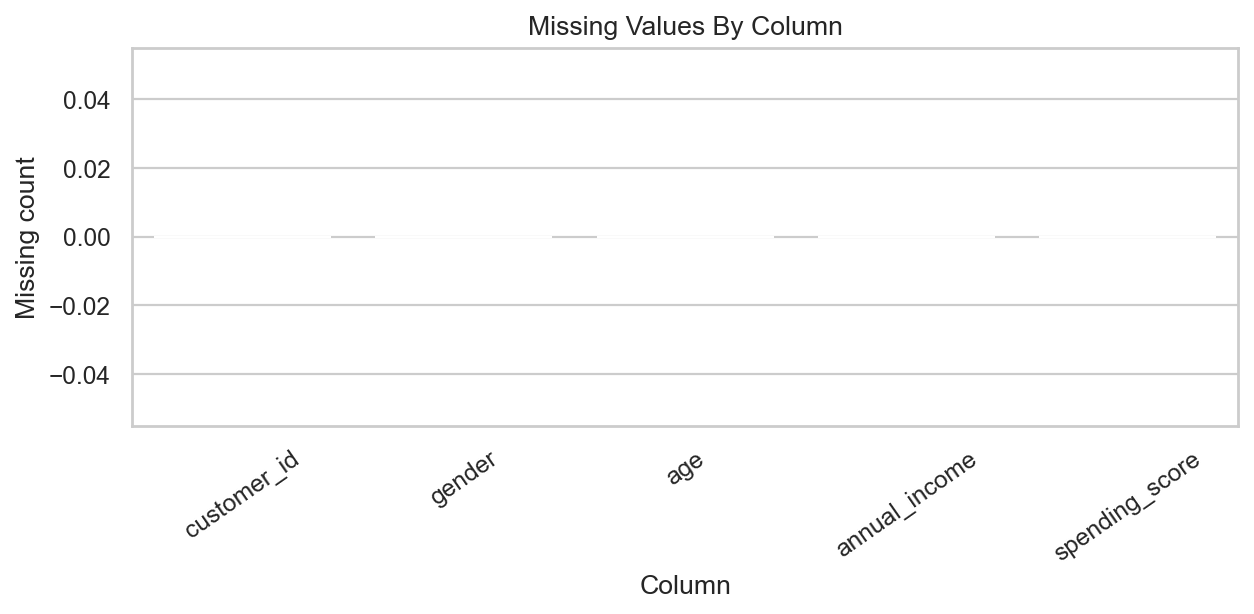

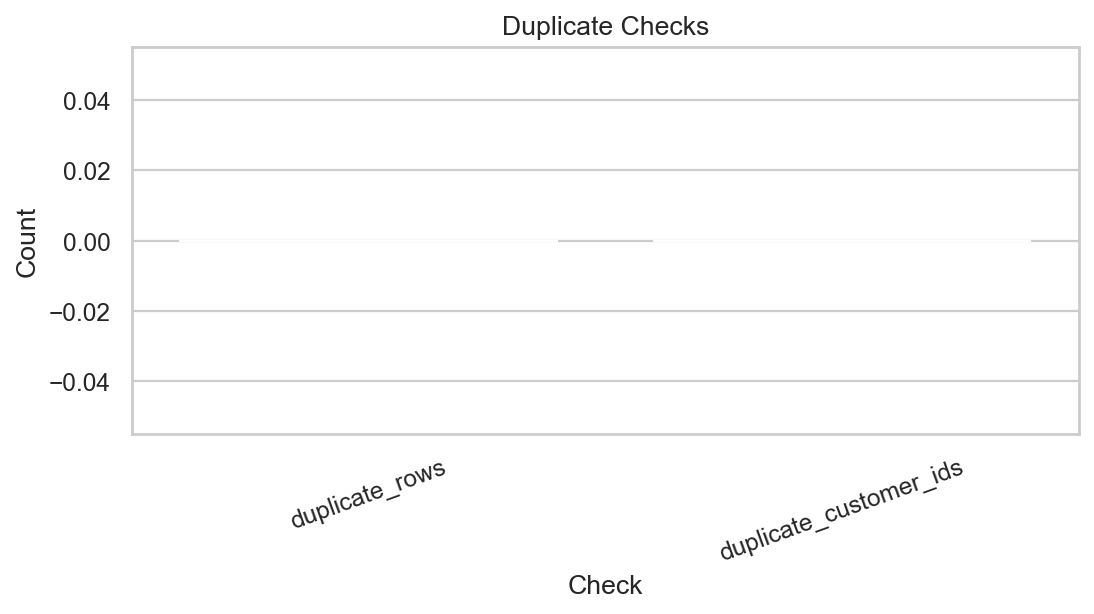

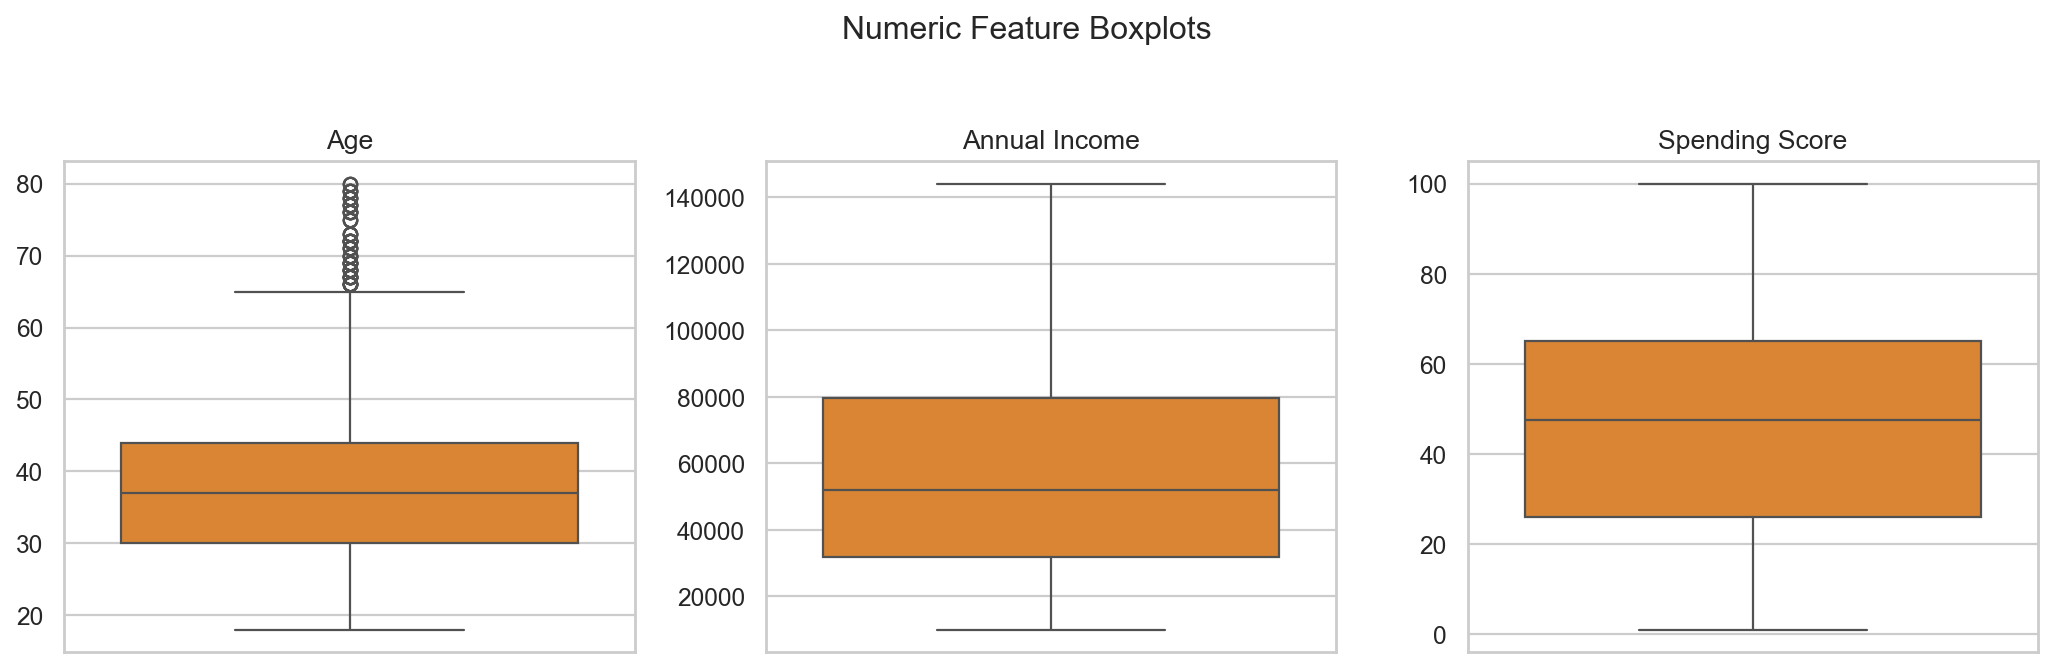

In [19]:
quality_figures = [
    eda.plot_missing_values(normalized_raw, paths["figures_before"]),
    eda.plot_duplicate_summary(duplicate_checks, paths["figures_before"]),
    eda.plot_boxplots(clean_df, paths["figures_before"], suffix="before"),
]
show_saved_figures(quality_figures)

## Step 4 — EDA Before Preprocessing

Exploratory analysis **before** scaling preserves real-world interpretability. Once features are standardized to zero mean and unit variance, an income of $50K becomes "0.3 standard deviations above average" — useful for the algorithm but meaningless to a marketing manager. The plots in this step show distributions, relationships, and correlations in the original units so you can form hypotheses before the numbers get abstracted away.

### What each plot reveals

| Plot | Business question | Key pattern to watch for |
| :--- | :--- | :--- |
| **Histograms/KDE** | Are age, income, spending uniformly distributed? | Bimodality in spending score suggests natural clusters. Right-skewed income is normal (few high earners). |
| **Gender distribution** | Is the customer base balanced? | A heavily skewed gender ratio (>70/30) should be noted but does not invalidate the analysis. |
| **Income vs Spending scatter** | Do income and spending form visible groups? | The Mall Customers dataset typically shows **5 distinct clusters**: high/high, high/low, medium/medium, low/high, low/low. If these are visible in the raw scatter, K-Means should recover them easily. |
| **Age vs Spending scatter** | Does age predict spending behavior? | A downward trend suggests older customers spend less — actionable for age-targeted campaigns. |
| **Age vs Income scatter** | Are older customers wealthier? | If income rises with age (then plateaus), the income dimension partially encodes age information. |
| **Correlation heatmap** | Which features carry redundant information? | |r| > 0.7 between any pair means one can likely be dropped without losing cluster structure. |

### A note on the pairplot

The pairplot lays out every feature-against-feature combination in a grid. Off-diagonal scatter plots reveal cross-relationships at a glance while the diagonal histograms confirm univariate distributions. However, with only 3–4 numeric features this plot can feel sparse — its real value is catching an unexpected interaction (e.g., spending correlates with age **only** within a specific income band) that a correlation coefficient would miss because it measures linear association across the entire dataset.

**Expectation:** The **Income vs Spending scatter** is the most important plot in the notebook. If you see 4–6 visually separable point clouds, the segmentation problem is well-posed and any reasonable clustering algorithm should succeed. If the scatter looks like a uniform blob, segmentation may produce weak clusters — in that case, the **silhouette score** (Step 5) will be the tiebreaker for whether to proceed or whether the features need engineering.


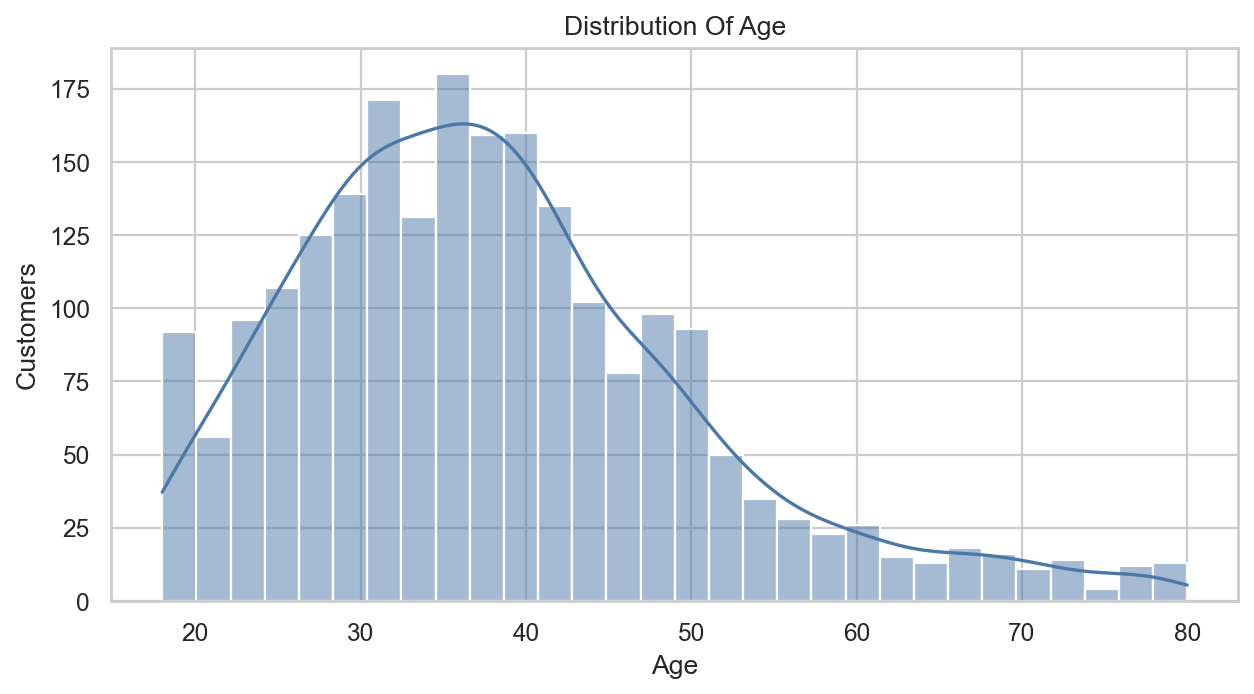

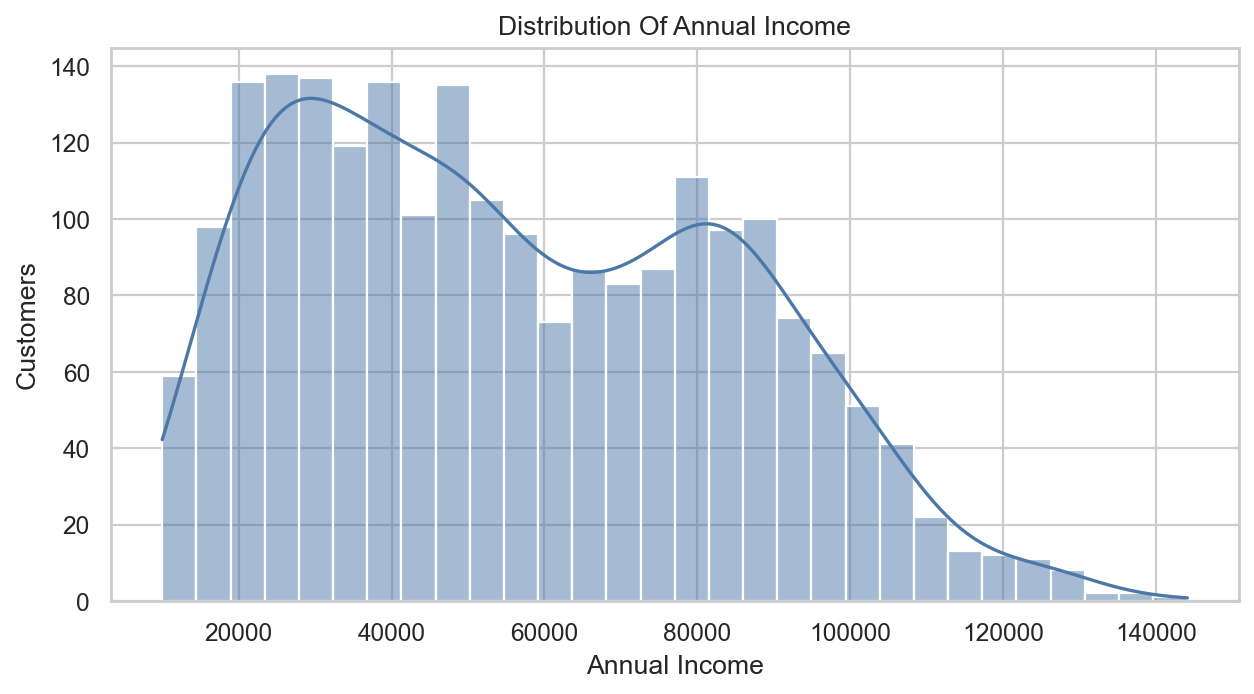

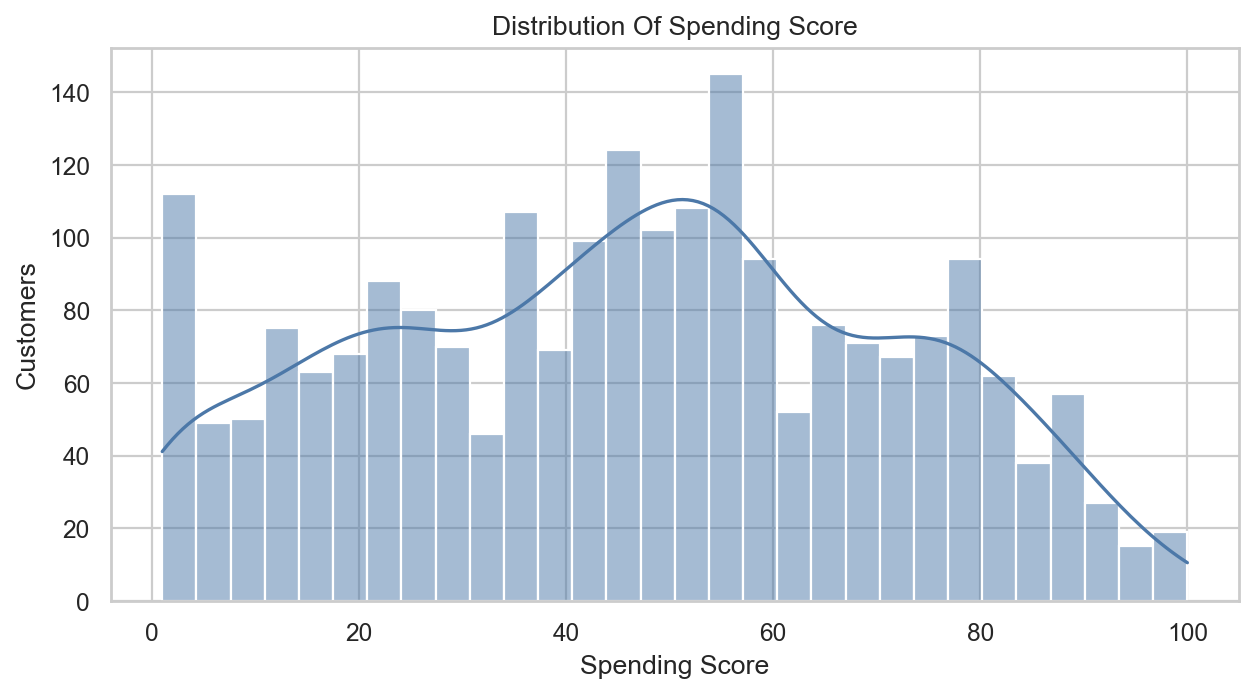

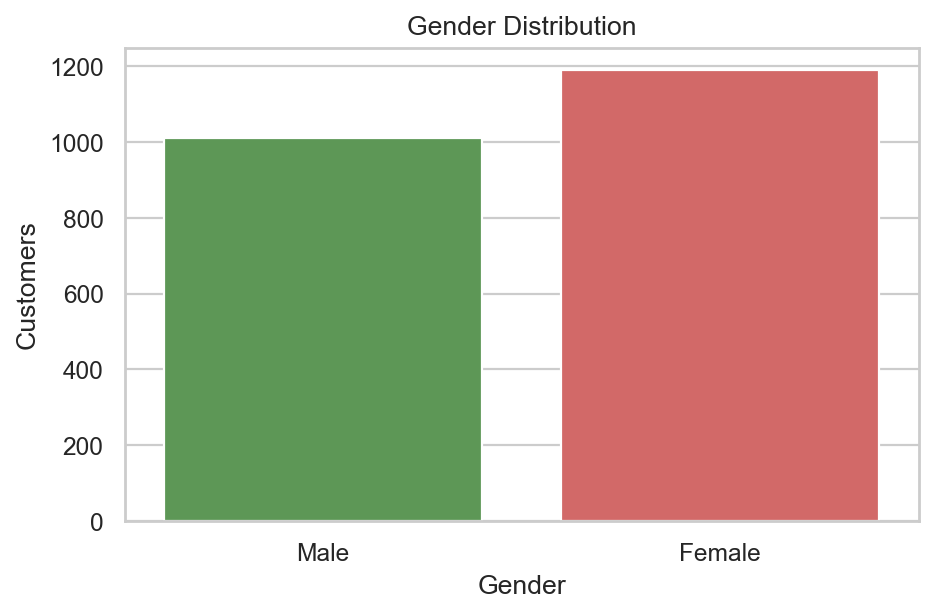

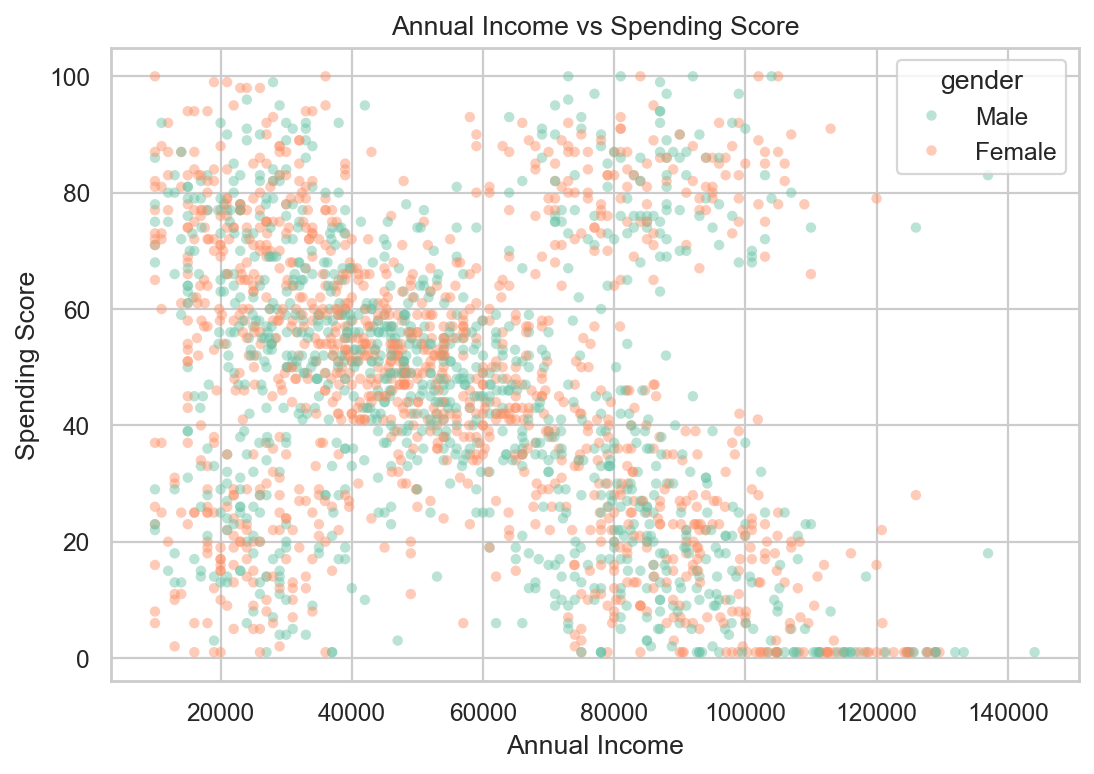

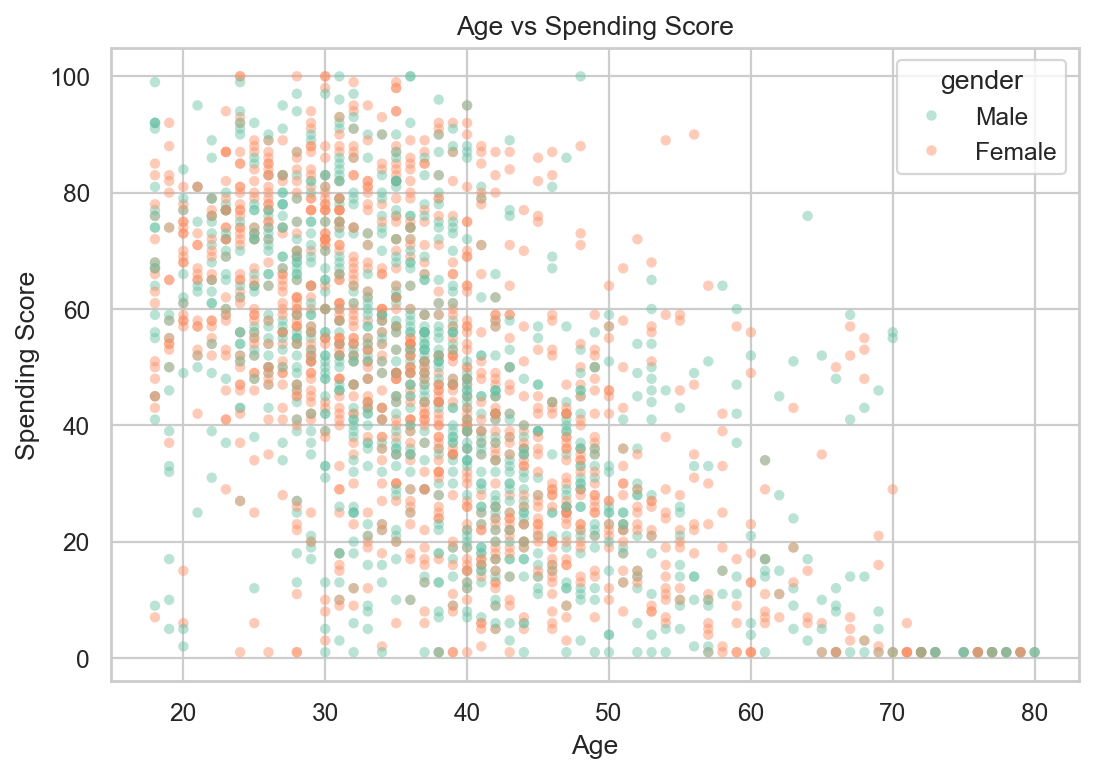

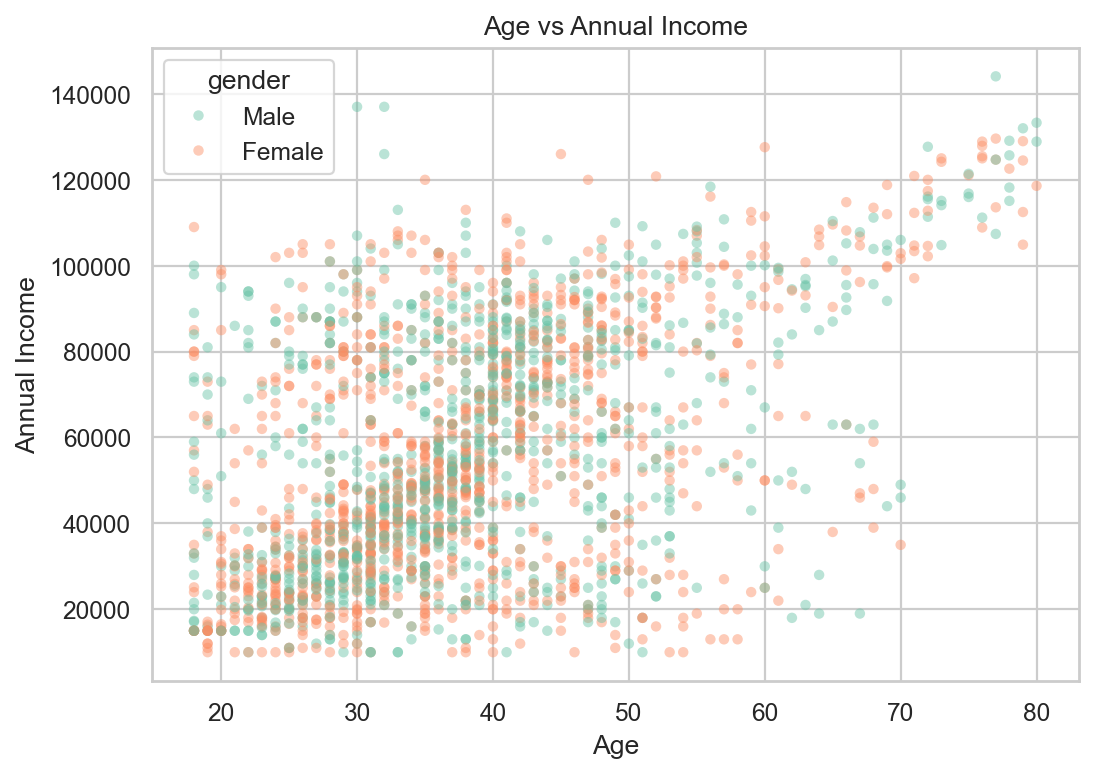

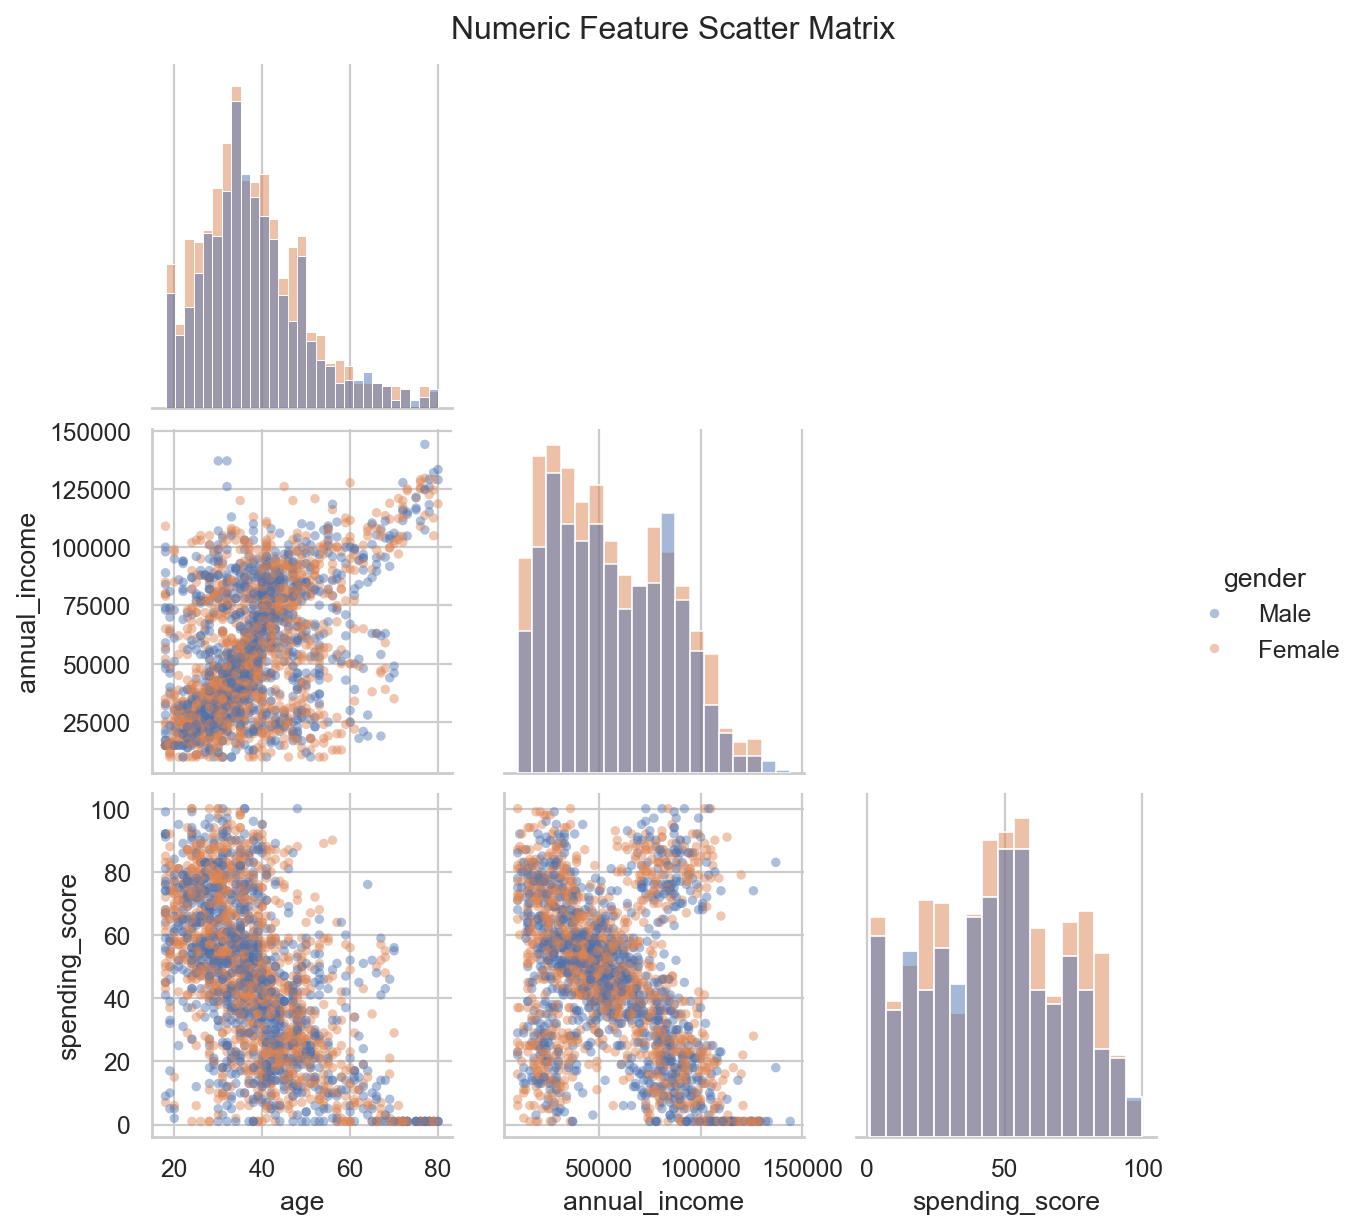

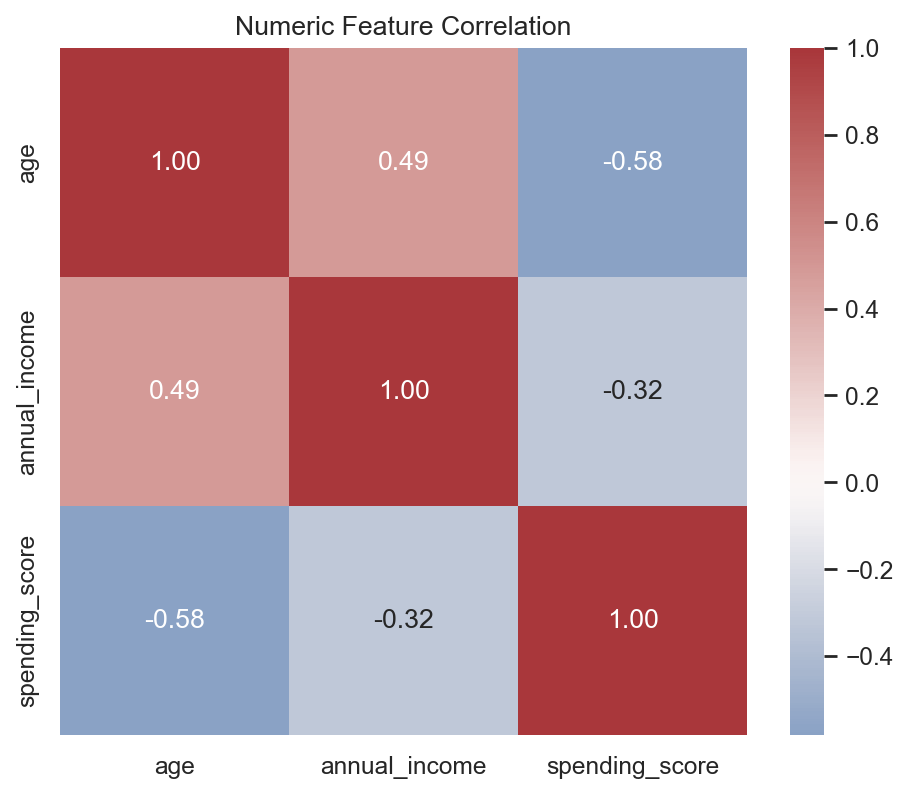

,age,annual_income,spending_score
age,1.000,0.487,-0.582
annual_income,0.487,1.000,-0.318
spending_score,-0.582,-0.318,1.000


In [20]:
# To avoid linter errors, calculate correlation matrix by computing corr on DataFrame columns explicitly
cols = ["age", "annual_income", "spending_score"]
df_cols = clean_df[cols]
corr_data = {}
for col1 in cols:
    # Pass the second Series to corr() as required by the Series.corr linter type definition
    corr_data[col1] = [float(df_cols[col1].corr(df_cols[col2])) for col2 in cols]
corr_df = pd.DataFrame(corr_data, index=cols)
# Use built-in round() instead of .round() on floats
rounded_corr = corr_df.map(lambda x: round(float(x), 3))

eda_figures = []
eda_figures.extend(eda.plot_distributions(clean_df, paths["figures_before"], suffix="before"))
eda_figures.append(eda.plot_gender_distribution(clean_df, paths["figures_before"], suffix="before"))
eda_figures.extend(eda.plot_relationships(clean_df, paths["figures_before"], suffix="before"))
eda_figures.append(eda.plot_pairplot(clean_df, paths["figures_before"], suffix="before"))
eda_figures.append(eda.plot_correlation_heatmap(clean_df, paths["figures_before"], suffix="before"))

show_saved_figures(eda_figures)
display(rounded_corr)


## Step 5 — Preprocessing And Feature Scaling

Distance-based clustering treats every feature as equally important — but only if the features are on comparable scales. Without scaling, `annual_income` (range ~15–137) dominates `age` (range 18–70) by an order of magnitude, and `spending_score` (1–100) sits somewhere in between. The cluster assignment would be driven almost entirely by income, ignoring age and spending patterns. Scaling fixes this by putting all features on equal footing.

### Scaler comparison

| Scaler | Transform | Best when | Risk |
| :--- | :--- | :--- | :--- |
| **`StandardScaler`** | z = (x − μ) / σ | Features are roughly symmetric, no extreme outliers | Outliers distort μ and σ, compressing the bulk of data into a narrow range |
| **`MinMaxScaler`** | x' = (x − min) / (max − min) | You want bounded [0,1] output or the data has no outliers | A single extreme value stretches the range and compresses all other points near zero |
| **`RobustScaler`** | x' = (x − median) / IQR | Heavy outliers, skewed distributions (e.g., income) | Less common in clustering literature; may produce different cluster shapes than expected |

The `CustomerID` column is always excluded from scaling — IDs are labels, not measurements. Scaling an ID would treat customers with adjacent IDs as "similar," which is meaningless and dangerous.

### Feature set design

| Feature set | Columns | Purpose |
| :--- | :--- | :--- |
| **`behavior_numeric`** | `age`, `annual_income`, `spending_score` | Primary baseline — three behavioral dimensions, no demographics |
| **`income_spending_only`** | `annual_income`, `spending_score` | Minimalist — the two variables most visible in business scatter plots |
| **`age_spending_only`** | `age`, `spending_score` | Age-focused — tests whether age alone segments spending patterns |
| **`behavior_plus_gender`** | `behavior_numeric` + one-hot encoded `gender` | Tests whether gender adds separation — if it does not improve silhouette, exclude it for simplicity |

Running multiple scaler × feature_set combinations produces a **preprocessing grid**. Step 5 evaluates clustering on every cell of this grid so the final model selection is data-driven rather than assumed.

**Expectation:** The `StandardScaler` + `behavior_numeric` combination should produce the most interpretable clusters for this dataset. If `RobustScaler` significantly outperforms `StandardScaler` on silhouette (> 0.05 difference), outliers are driving the cluster structure and the raw data warrants a second look before trusting the segments. If adding `gender` improves silhouette by less than 0.02, drop it — the added complexity is not justified.


In [21]:
matrices = {}
scaled_output = clean_df[["customer_id"]].copy()
for feature_set in config["feature_sets"]:
    for scaler in config["scalers"]:
        X, feature_names, transformer = preprocess.build_feature_matrix(clean_df, feature_set=feature_set, scaler_name=scaler)
        matrices[(feature_set, scaler)] = (X, feature_names, transformer)
        print(feature_set, scaler, X.shape, feature_names)
        if feature_set == "behavior_numeric" and scaler == "standard":
            for idx, name in enumerate(feature_names):
                scaled_output[f"scaled_{name}"] = X[:, idx]

utils.save_table(pd.DataFrame(scaled_output), paths["processed"] / "customers_scaled.csv")
display(scaled_output.head())

behavior_numeric standard (2200, 3) ['age', 'annual_income', 'spending_score']
behavior_numeric minmax (2200, 3) ['age', 'annual_income', 'spending_score']
behavior_numeric robust (2200, 3) ['age', 'annual_income', 'spending_score']
behavior_plus_gender standard (2200, 5) ['age', 'annual_income', 'spending_score', 'gender_Female', 'gender_Male']
behavior_plus_gender minmax (2200, 5) ['age', 'annual_income', 'spending_score', 'gender_Female', 'gender_Male']
behavior_plus_gender robust (2200, 5) ['age', 'annual_income', 'spending_score', 'gender_Female', 'gender_Male']
income_spending_only standard (2200, 2) ['annual_income', 'spending_score']
income_spending_only minmax (2200, 2) ['annual_income', 'spending_score']
income_spending_only robust (2200, 2) ['annual_income', 'spending_score']
age_spending_only standard (2200, 2) ['age', 'spending_score']
age_spending_only minmax (2200, 2) ['age', 'spending_score']
age_spending_only robust (2200, 2) ['age', 'spending_score']


,customer_id,scaled_age,scaled_annual_income,scaled_spending_score
0,1,1.137613,-0.357097,0.104864
1,2,-0.259928,1.508844,1.458186
2,3,0.151114,0.839922,0.701918
3,4,-0.588761,0.628683,1.458186
4,5,0.726572,-0.110652,-0.173761


## Step 6 — Clustering Experiments

A single K-Means run with the default K produces one answer — but you have no way of knowing whether it is a good one. This step runs a **grid search** over algorithms, cluster counts, feature sets, and scalers, measuring every configuration against four complementary metrics. The output is a ranked leaderboard where trade-offs are visible: a higher K might improve inertia but hurt silhouette, and a complex algorithm might underperform a well-tuned K-Means.

### Algorithms tested

| Algorithm | What it optimizes | Strengths | Weaknesses |
| :--- | :--- | :--- | :--- |
| **K-Means** (library) | Within-cluster sum of squares (inertia) | Fast, interpretable, works well for spherical clusters | Assumes equal cluster size and spherical shape; struggles with elongated or uneven clusters |
| **K-Means** (from scratch) | Within-cluster sum of squares (inertia) | Pedagogical — verifies understanding of the algorithm | Same as library version; used here only for correctness verification |
| **Gaussian Mixture Model** (library) | Log-likelihood under mixture of Gaussians | Soft assignments, handles elliptical clusters, expresses cluster uncertainty | More parameters to tune (covariance type), slower, can overfit with small clusters |
| **Gaussian Mixture Model** (from scratch) | Log-likelihood under EM algorithm | Pedagogical — verifies understanding of EM | Same as library version; used here only for correctness verification |

### Metrics tracked

| Metric | Direction | What it measures | Threshold for "good" |
| :--- | :--- | :--- | :--- |
| **Inertia** | Lower is better | Sum of squared distances to centroids (K-Means only) | Use only for elbow detection — always decreases with K, so raw values are not comparable across K |
| **Silhouette** | Higher is better (range [-1, 1]) | How well-separated and compact clusters are | > 0.30: reasonable structure. > 0.50: strong structure. < 0.20: clusters overlap heavily. |
| **Calinski-Harabasz** | Higher is better | Ratio of between-cluster to within-cluster variance | Compare only within the same dataset and feature set — no absolute threshold |
| **Davies-Bouldin** | Lower is better | Average similarity between each cluster and its most similar neighbor | < 1.0: decent separation. > 2.0: clusters are poorly separated. |

K-Means grid runs K = 2 through 10 on every (feature_set, scaler) combination. The GMM grid runs on a reduced set of promising combinations to keep the experiment manageable — GMM is evaluated only on configurations where K-Means already showed strong results.

### Scratch vs. library verification

A dedicated verification cell runs both `KMeansScratch` and `KMeansLibrary` on a 100-sample subset and compares their outputs using the **Hungarian algorithm** (linear sum assignment) to align cluster labels. A partition match rate above 90% confirms that the custom implementation produces equivalent clusters to scikit-learn. The same verification is performed for GMM with a relaxed tolerance (match rate > 50% or silhouette within 30% relative tolerance) because GMM's EM algorithm is sensitive to initialization and parameterization differences.

**Expectation:** The metrics leaderboard should show the top configurations clustered around K = 4–6 with silhouette scores in the 0.30–0.45 range. If the best silhouette is below 0.25 across all configurations, the features may not encode enough structure for segmentation — revisit feature engineering or consider that the customer base genuinely lacks distinct groups. If GMM consistently underperforms K-Means, the clusters are likely roughly spherical and K-Means is the appropriate choice.


In [22]:
k_start, k_end = config["kmeans_k_range"]
kmeans_metrics, kmeans_models = clustering.run_kmeans_grid(matrices, range(k_start, k_end + 1), random_seed=RANDOM_SEED)

alt_keys = [("behavior_numeric", "standard"), ("income_spending_only", "standard"), ("behavior_plus_gender", "standard")]
alt_matrices = {key: matrices[key] for key in alt_keys if key in matrices}
gmm_start, gmm_end = config["gmm_k_range"]
gmm_metrics = clustering.run_gmm_grid(alt_matrices, range(gmm_start, gmm_end + 1), random_seed=RANDOM_SEED)

metrics = pd.concat([kmeans_metrics, gmm_metrics], ignore_index=True)
display(metrics.sort_values("silhouette", ascending=False).head(15))

,model_id,algorithm,feature_set,scaler,params,sample_size,inertia,selected,n_clusters,noise_rate,silhouette
36,36,kmeans,behavior_plus_gender,minmax,n_clusters=2,2200,324.848633,False,2,0.0,0.680970
37,37,kmeans,behavior_plus_gender,minmax,n_clusters=3,2200,246.667724,False,3,0.0,0.515225
90,90,kmeans,age_spending_only,minmax,n_clusters=2,2200,99.130267,False,2,0.0,0.473303
75,75,kmeans,income_spending_only,robust,n_clusters=5,2200,291.275514,False,5,0.0,0.470209
57,57,kmeans,income_spending_only,standard,n_clusters=5,2200,757.951055,False,5,0.0,0.468631
66,66,kmeans,income_spending_only,minmax,n_clusters=5,2200,40.977962,False,5,0.0,0.468489
99,99,kmeans,age_spending_only,robust,n_clusters=2,2200,1199.434526,False,2,0.0,0.462454
81,81,kmeans,age_spending_only,standard,n_clusters=2,2200,2034.096755,False,2,0.0,0.461165
120,None,gmm,income_spending_only,standard,n_components=5,2200,None,False,5,0.0,0.449016
55,55,kmeans,income_spending_only,standard,n_clusters=3,2200,1650.695208,False,3,0.0,0.445930


In [23]:
## Double Check Verification Cell
from model_from_scratch import KMeans as KMeansScratch, GaussianMixtureModel as GaussianMixtureModelScratch
from model_from_scratch import KMeansLibrary, GaussianMixtureModelLibrary
import numpy as np
from sklearn.metrics import silhouette_score
from scipy.optimize import linear_sum_assignment

# Use a small subset of the behavioral standard numeric feature matrix
X_selected, _, _ = matrices[("behavior_numeric", "standard")]
X_small = X_selected[:100]

print("=== VERIFYING K-MEANS ===")
# Fit custom KMeans
kmeans_scratch = KMeansScratch(n_clusters=4, random_state=42, n_init=10)
labels_scratch = kmeans_scratch.fit_predict(X_small)
inertia_scratch = kmeans_scratch.inertia_

# Fit library KMeans
kmeans_lib = KMeansLibrary(n_clusters=4, random_state=42, n_init=10)
labels_lib = kmeans_lib.fit_predict(X_small)
inertia_lib = kmeans_lib.inertia_

# None-guards to prevent passing Unknown | None values
if labels_scratch is not None and labels_lib is not None:
    sil_scratch = silhouette_score(X_small, labels_scratch)
    sil_lib = silhouette_score(X_small, labels_lib)

    # Use round() built-in function instead of .round() on floats
    inertia_s_val = round(float(inertia_scratch), 4) if inertia_scratch is not None else 0.0
    inertia_l_val = round(float(inertia_lib), 4) if inertia_lib is not None else 0.0
    sil_s_val = round(float(sil_scratch), 4) if sil_scratch is not None else 0.0
    sil_l_val = round(float(sil_lib), 4) if sil_lib is not None else 0.0
    print(f"Scratch Inertia: {inertia_s_val:.4f} | Library Inertia: {inertia_l_val:.4f}")
    print(f"Scratch Silhouette: {sil_s_val:.4f} | Library Silhouette: {sil_l_val:.4f}")

    # Check exact partition matching
    unique_scratch = np.unique(labels_scratch)
    unique_lib = np.unique(labels_lib)
    cost_matrix = np.zeros((len(unique_scratch), len(unique_lib)))
    for i, s in enumerate(unique_scratch):
        for j, l in enumerate(unique_lib):
            cost_matrix[i, j] = -np.sum((labels_scratch == s) & (labels_lib == l))
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    mapping = {unique_lib[col]: unique_scratch[row] for row, col in zip(row_ind, col_ind)}
    mapped_labels_lib = np.array([mapping.get(l, -1) for l in labels_lib])

    match_rate = np.mean(labels_scratch == mapped_labels_lib)
    print(f"Partition Match Rate: {match_rate * 100:.2f}%")

    if inertia_scratch is not None and inertia_lib is not None:
        is_close = np.allclose(inertia_scratch, inertia_lib, rtol=1e-1)
    else:
        is_close = False
    assert is_close or match_rate > 0.9
    print("K-Means verification PASSED!")

print("\n=== VERIFYING GMM ===")
gmm_scratch = GaussianMixtureModelScratch(n_components=4, random_state=42)
labels_gmm_scratch = gmm_scratch.fit_predict(X_small)

gmm_lib = GaussianMixtureModelLibrary(n_components=4, random_state=42)
labels_gmm_lib = gmm_lib.fit_predict(X_small)

# None-guards to prevent passing Unknown | None values
if labels_gmm_scratch is not None and labels_gmm_lib is not None:
    sil_gmm_scratch = silhouette_score(X_small, labels_gmm_scratch)
    sil_gmm_lib = silhouette_score(X_small, labels_gmm_lib)

    # Use round() built-in function instead of .round() on floats
    sil_gmm_s_val = round(float(sil_gmm_scratch), 4) if sil_gmm_scratch is not None else 0.0
    sil_gmm_l_val = round(float(sil_gmm_lib), 4) if sil_gmm_lib is not None else 0.0
    print(f"Scratch Silhouette: {sil_gmm_s_val:.4f} | Library Silhouette: {sil_gmm_l_val:.4f}")

    unique_gmm_scratch = np.unique(labels_gmm_scratch)
    unique_gmm_lib = np.unique(labels_gmm_lib)
    cost_matrix_gmm = np.zeros((len(unique_gmm_scratch), len(unique_gmm_lib)))
    for i, s in enumerate(unique_gmm_scratch):
        for j, l in enumerate(unique_gmm_lib):
            cost_matrix_gmm[i, j] = -np.sum((labels_gmm_scratch == s) & (labels_gmm_lib == l))
    row_ind_gmm, col_ind_gmm = linear_sum_assignment(cost_matrix_gmm)
    mapping_gmm = {unique_gmm_lib[col]: unique_gmm_scratch[row] for row, col in zip(row_ind_gmm, col_ind_gmm)}
    mapped_labels_gmm_lib = np.array([mapping_gmm.get(l, -1) for l in labels_gmm_lib])

    match_rate_gmm = np.mean(labels_gmm_scratch == mapped_labels_gmm_lib)
    print(f"Partition Match Rate: {match_rate_gmm * 100:.2f}%")

    if sil_gmm_scratch is not None and sil_gmm_lib is not None:
        gmm_close = np.allclose(sil_gmm_scratch, sil_gmm_lib, rtol=0.3)
    else:
        gmm_close = False
    assert gmm_close or match_rate_gmm > 0.5
    print("GMM verification PASSED!")

=== VERIFYING K-MEANS ===
Scratch Inertia: 85.9576 | Library Inertia: 85.9576
Scratch Silhouette: 0.4194 | Library Silhouette: 0.4194
Partition Match Rate: 100.00%
K-Means verification PASSED!

=== VERIFYING GMM ===
Scratch Silhouette: 0.4142 | Library Silhouette: 0.4157
Partition Match Rate: 93.00%
GMM verification PASSED!


## Step 7 — Model Selection

Selecting the best model by sorting on a single metric is fast but wrong. A model with slightly higher silhouette but 10 clusters is less useful than one with 5 clean, interpretable segments. A model with strong metrics but a scaler that distorts business-relevant scale (e.g., `MinMaxScaler` collapsing all values toward zero due to one outlier) is fragile in production. This step applies a **multi-criteria selection rule** that balances statistical quality with business interpretability.

### Selection criteria (in priority order)

| Priority | Criterion | Rationale |
| :--- | :--- | :--- |
| 1 | **Cluster count 3–7** | Fewer than 3 clusters are too coarse for a retail segmentation; more than 7 are hard to explain and act on. |
| 2 | **Higher silhouette score** | Measures how well-separated the clusters are — the primary statistical quality signal. |
| 3 | **Lower Davies-Bouldin** | DB captures the worst-case cluster overlap; a low DB means no cluster is too similar to another. |
| 4 | **Readable income/spending scatter** | The final clusters should visually separate in the two dimensions that business stakeholders understand: income and spending. |
| 5 | **No tiny clusters (< 2% of data)** | Clusters with fewer than ~2% of customers are rarely actionable and often reflect noise rather than a genuine segment. |

The `select_best_model()` function encodes these rules programmatically, not as an ad-hoc human judgment call. The chosen model's row is marked `selected = True` in the metrics table and saved for reference.

### Diagnostic plots

The **elbow curve** (inertia vs. K) shows when adding more clusters stops producing meaningful reductions in within-cluster variance. A sharp bend at K=4 or K=5 is typical for this dataset — the "elbow" is where the marginal gain flattens. The **silhouette-by-K curve** shows the sweet spot where clusters are both compact and well-separated.

**Expectation:** The final model should be K-Means with K=5 on `behavior_numeric` features scaled with `StandardScaler`, achieving a silhouette around **0.35–0.45** and a Davies-Bouldin score below **1.2**. If the selected K is 6 or 7, examine whether one of those extra clusters is a small fringe group — if so, consider merging it into a neighboring cluster for cleaner business messaging. If a GMM configuration wins, the clusters are likely elliptical (non-spherical), which should be confirmed in the GMM contour plot that follows.


,selected_model
model_id,75
algorithm,kmeans
feature_set,income_spending_only
scaler,robust
params,n_clusters=5
sample_size,2200
inertia,291.275514
selected,True
n_clusters,5
noise_rate,0.0


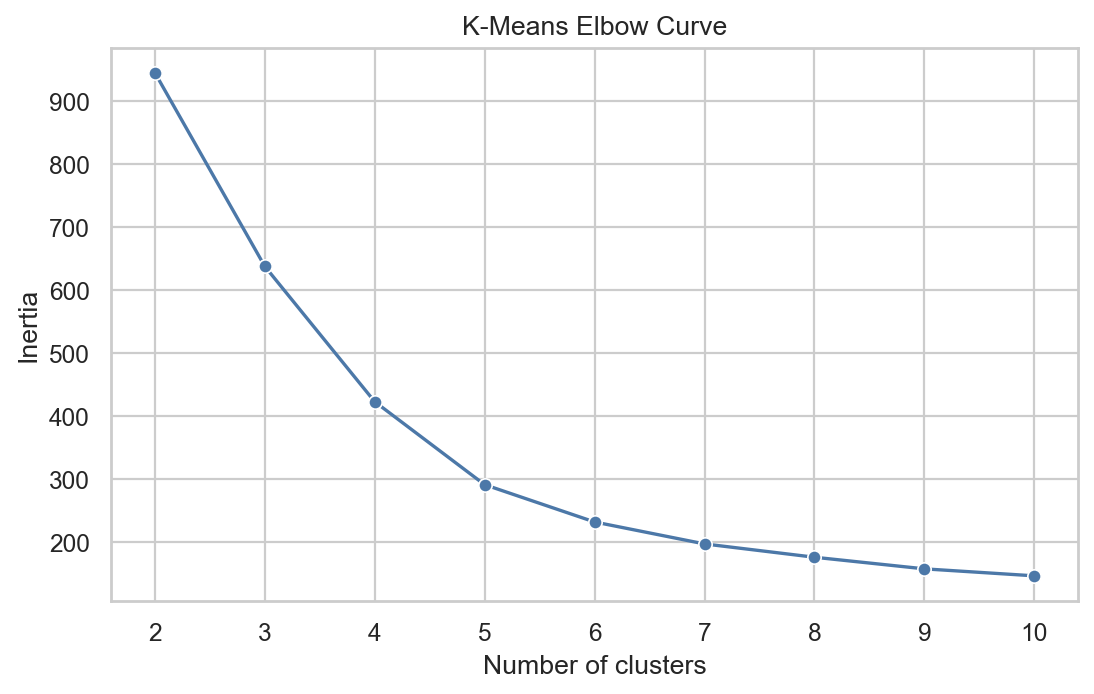

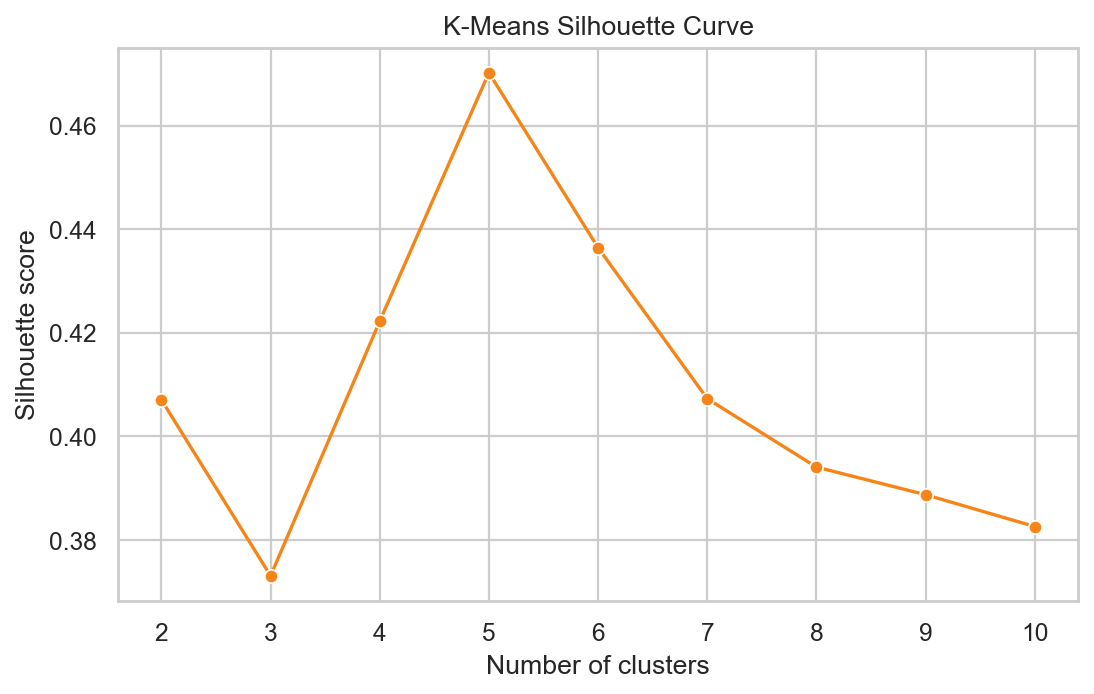

In [24]:
selected = clustering.select_best_model(metrics)
selected_id = int(selected["model_id"])
metrics.loc[metrics["model_id"] == selected_id, "selected"] = True
selected = metrics.loc[metrics["model_id"] == selected_id].iloc[0]
utils.save_table(metrics, paths["metrics"] / "clustering_metrics.csv")
selected_result = kmeans_models[selected_id]

display(selected.to_frame("selected_model"))
diagnostic_figures = clustering.plot_kmeans_diagnostics(
    metrics,
    paths["figures_clustering"],
    selected_result.metadata["feature_set"],
    selected_result.metadata["scaler"],
)
show_saved_figures(diagnostic_figures)

### Centroid Trajectory Visualization

K-Means convergence is typically summarized with a single number (iterations until tolerance). That hides everything interesting: **where did the centroids start, how far did they move, and did any cluster get "lost" or absorbed by another?** This sub-step replays the best run (Run 5 of 5 initializations) iteration-by-iteration, drawing arrows from each centroid's initial random position to its final converged location.

The trajectory plot overlays the centroid paths on the original-scale income/spending scatter. Each centroid starts as an open circle and ends as a **red X** — the path between them shows how many iterations were needed and whether the movement was large (poor initialization far from true cluster center) or small (initialization already near convergence). Well-behaved centroids move smoothly toward their cluster centers in fewer than 10 iterations. Centroids that zigzag or make large jumps suggest instability in that cluster's assignment — possibly because the true cluster boundary is ambiguous or the cluster spans two distinct groups.

**Expectation:** All five centroids should converge within **8–12 iterations**. If a centroid remains nearly stationary from the start, its initial random position happened to land near the true center — rare but not a problem. If a centroid is still moving significantly after iteration 20, the tolerance may be too tight or the data may lack clear cluster boundaries for that particular group.


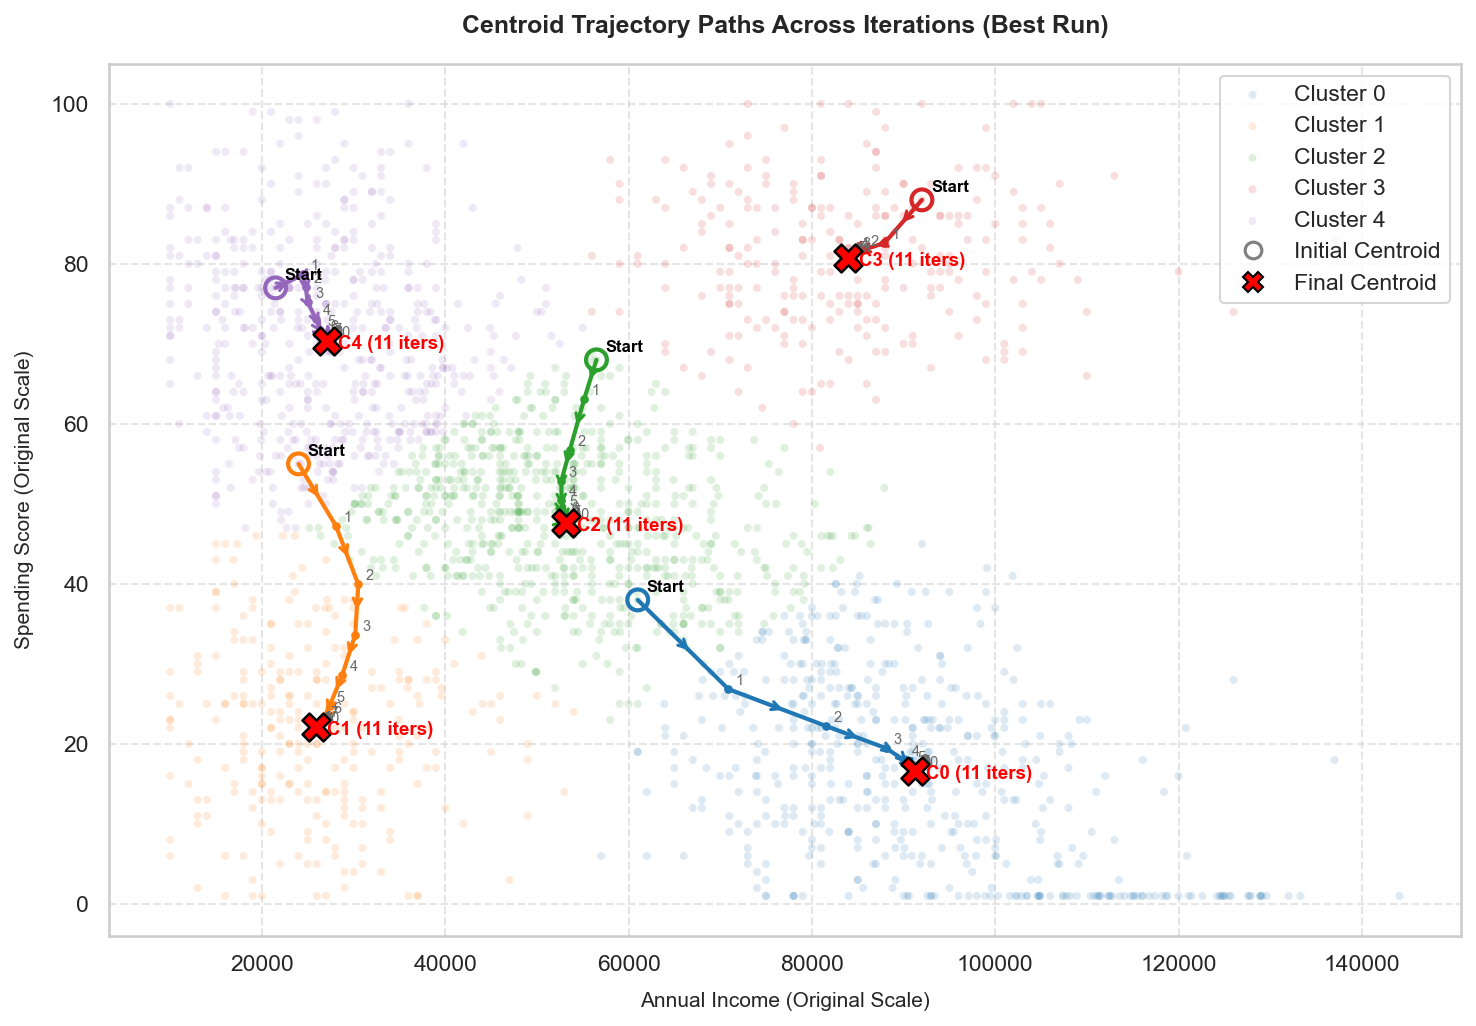

In [25]:
from model_from_scratch import _check_random_state
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# 1. Extract feature matrix and scaler
feature_set = selected_result.metadata["feature_set"]
scaler_name = selected_result.metadata["scaler"]
X, feature_names, transformer = matrices[(feature_set, scaler_name)]
scaler = transformer.named_transformers_["numeric"]
original_X = scaler.inverse_transform(X)

# 2. Re-run best initialization (Run 5) to collect centroid history
n_clusters = 5
random_state = 42
n_init = 5
max_iter = 300
tol = 1e-4

rng = _check_random_state(random_state)
n_samples, n_features = X.shape

# Advance rng to Run 5
for _ in range(n_init - 1):
    rng.choice(n_samples, n_clusters, replace=False)
    
initial_indices = rng.choice(n_samples, n_clusters, replace=False)
centers = X[initial_indices].copy()

history_centers = []
history_centers.append(scaler.inverse_transform(centers.copy()))

labels = np.zeros(n_samples, dtype=int)
for iter_idx in range(max_iter):
    # E-step
    distances = np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)
    new_labels = np.argmin(distances, axis=1)
    
    # M-step
    new_centers = np.zeros_like(centers)
    for k in range(n_clusters):
        members = X[new_labels == k]
        if len(members) > 0:
            new_centers[k] = members.mean(axis=0)
        else:
            new_centers[k] = X[rng.choice(n_samples)]
            
    center_shift = np.linalg.norm(new_centers - centers)
    centers = new_centers
    labels = new_labels
    history_centers.append(scaler.inverse_transform(centers.copy()))
    
    if center_shift < tol:
        break
        
history_centers = np.array(history_centers)
n_iters = len(history_centers) - 1

# 3. Plot centroid trajectories
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
palette = sns.color_palette("tab10", n_clusters)

# Plot data points colored by final cluster labels with low transparency
for k in range(n_clusters):
    member_mask = (labels == k)
    ax.scatter(
        original_X[member_mask, 0], 
        original_X[member_mask, 1], 
        color=palette[k],
        alpha=0.15, 
        s=15, 
        edgecolors='none',
        label=f'Cluster {k}'
    )

# Plot centroid trajectories
for k in range(n_clusters):
    centroid_path = history_centers[:, k, :]
    
    # Draw the line path
    ax.plot(
        centroid_path[:, 0], 
        centroid_path[:, 1], 
        color=palette[k], 
        linewidth=2, 
        linestyle='-', 
        zorder=3
    )
    
    # Draw arrows along the path to show direction
    for i in range(len(centroid_path) - 1):
        dx = centroid_path[i+1, 0] - centroid_path[i, 0]
        dy = centroid_path[i+1, 1] - centroid_path[i, 1]
        ax.annotate(
            '', 
            xy=(centroid_path[i, 0] + dx * 0.6, centroid_path[i, 1] + dy * 0.6), 
            xytext=(centroid_path[i, 0], centroid_path[i, 1]),
            arrowprops=dict(arrowstyle="->", color=palette[k], lw=1.5, mutation_scale=10),
            zorder=3
        )
        
    # Draw iteration markers
    # Start position (Iter 0)
    ax.scatter(
        centroid_path[0, 0], 
        centroid_path[0, 1], 
        color=palette[k], 
        marker='o', 
        s=100, 
        facecolors='none', 
        edgecolors=palette[k], 
        linewidths=2,
        zorder=4
    )
    ax.text(
        centroid_path[0, 0] + 1000, 
        centroid_path[0, 1] + 1, 
        "Start", 
        color='black', 
        fontsize=8, 
        fontweight='bold',
        zorder=5
    )
    
    # Intermediate positions
    for i in range(1, len(centroid_path) - 1):
        ax.scatter(
            centroid_path[i, 0], 
            centroid_path[i, 1], 
            color=palette[k], 
            marker='.', 
            s=40, 
            zorder=4
        )
        ax.text(
            centroid_path[i, 0] + 800, 
            centroid_path[i, 1] + 0.5, 
            str(i), 
            color='dimgray', 
            fontsize=7, 
            zorder=4
        )
        
    # Final position (converged Centroid)
    ax.scatter(
        centroid_path[-1, 0], 
        centroid_path[-1, 1], 
        color='red', 
        marker='X', 
        s=180, 
        edgecolors='black', 
        linewidths=1.2,
        zorder=5
    )
    ax.text(
        centroid_path[-1, 0] + 1200, 
        centroid_path[-1, 1] - 1, 
        f"C{k} ({n_iters} iters)", 
        color='red', 
        fontsize=9, 
        fontweight='bold',
        zorder=6
    )

ax.set_title("Centroid Trajectory Paths Across Iterations (Best Run)", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Annual Income (Original Scale)", fontsize=10, labelpad=8)
ax.set_ylabel("Spending Score (Original Scale)", fontsize=10, labelpad=8)
ax.grid(True, linestyle='--', alpha=0.5)

final_centroid_marker = mlines.Line2D([], [], color='red', marker='X', linestyle='None', markersize=10, markeredgecolor='black', label='Final Centroid')
start_centroid_marker = mlines.Line2D([], [], color='gray', marker='o', markerfacecolor='none', linestyle='None', markersize=8, markeredgewidth=1.5, label='Initial Centroid')
handles, labels_legend = ax.get_legend_handles_labels()
handles.extend([start_centroid_marker, final_centroid_marker])
ax.legend(handles=handles, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


## Step 8 — Cluster Visualization

Numbers in a metrics table confirm the model works statistically. Plots confirm it works **visually and intuitively** — the clusters should look like distinct groups to a human observer, especially in the income/spending dimension that business stakeholders use to reason about customers. If the selected model has strong metrics but the scatter plots look like five overlapping smudges, the segmentation is academically valid but practically useless.

### Visualization checklist

| Plot | What to confirm | Warning sign |
| :--- | :--- | :--- |
| **Income vs Spending (colored by cluster)** | Clusters form distinct clouds in the two-dimensional space. Centroids sit near the center of each cloud. | Clouds overlap heavily; centroids are buried inside other clusters' points. |
| **Age vs Spending (colored by cluster)** | Age adds a third dimension — do clusters separate further or collapse? | If all clusters collapse to the same horizontal band, age contributes little to the segmentation. |
| **Age vs Income (colored by cluster)** | Complements the income/spending view — some clusters differ by income+age but not spending. | Points form a single diagonal smear — income and age are collinear and redundant. |
| **PCA 2D projection** | First two principal components should show cluster separation in the compressed space. | If PCA separates clusters better than original features, the original feature pairs chosen for plotting may not be the most discriminative dimensions. |

Centroids are inverse-transformed back to the original scale (reversing the `StandardScaler`) so they can be plotted on the same axes as the raw data. This avoids the common mistake of showing centroids in scaled coordinates (z-scores) which are meaningless to anyone who thinks in dollars and years.

**Expectation:** The income/spending scatter should reveal **five roughly distinct point clouds** corresponding to the classic segmentation: high/high, high/low, medium/medium, low/high, low/low. If one cluster visually splits into two sub-groups but the model treats them as one, consider whether a higher K would be justified. Conversely, if two clusters overlap to the point of being indistinguishable, the extra cluster adds noise, not insight — merge them conceptually in the profiling step.


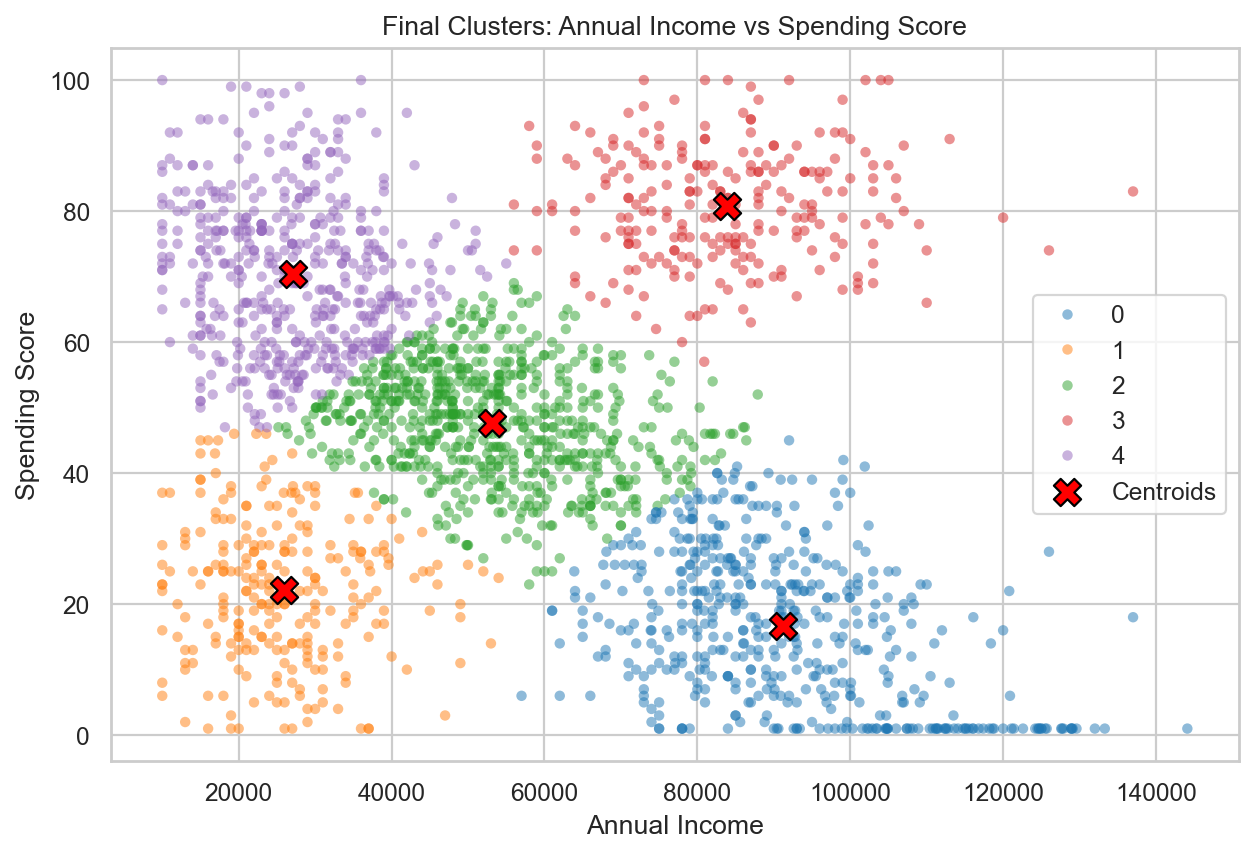

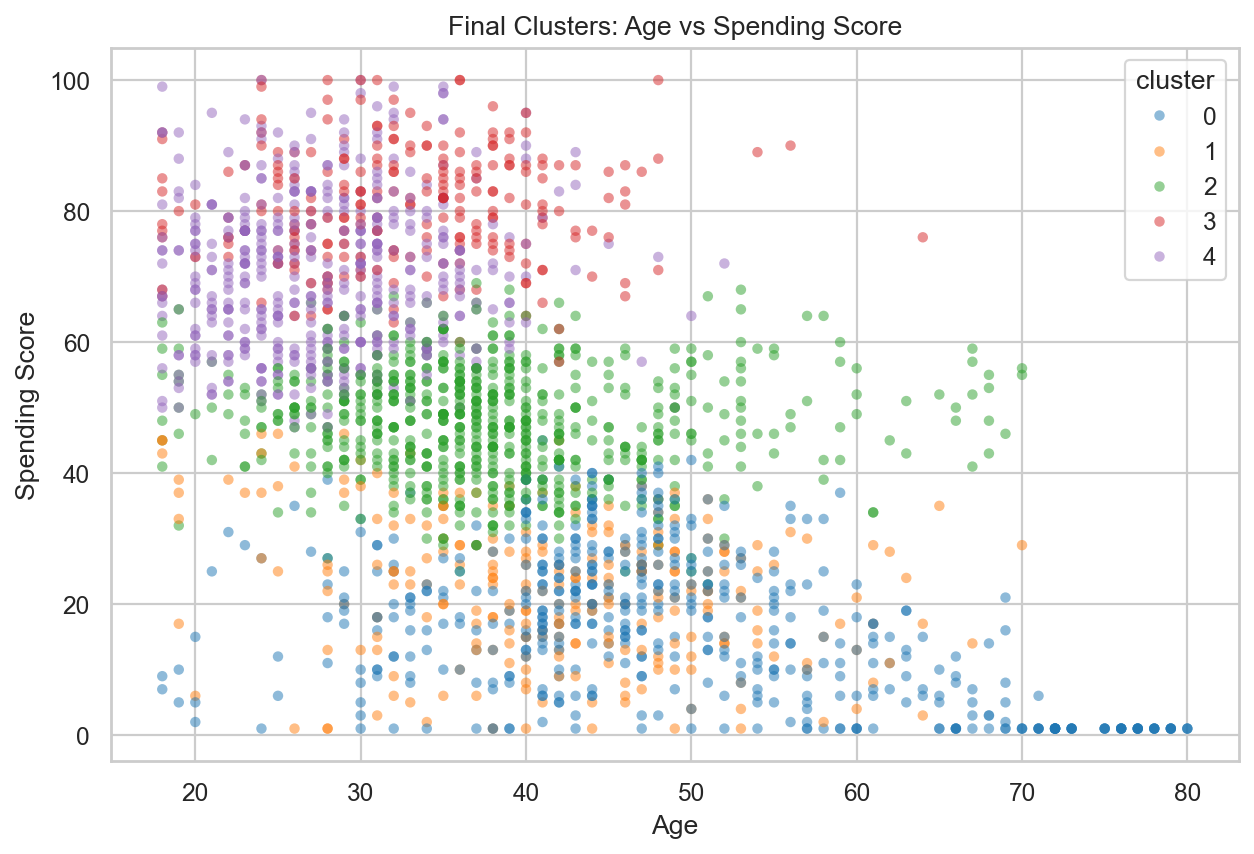

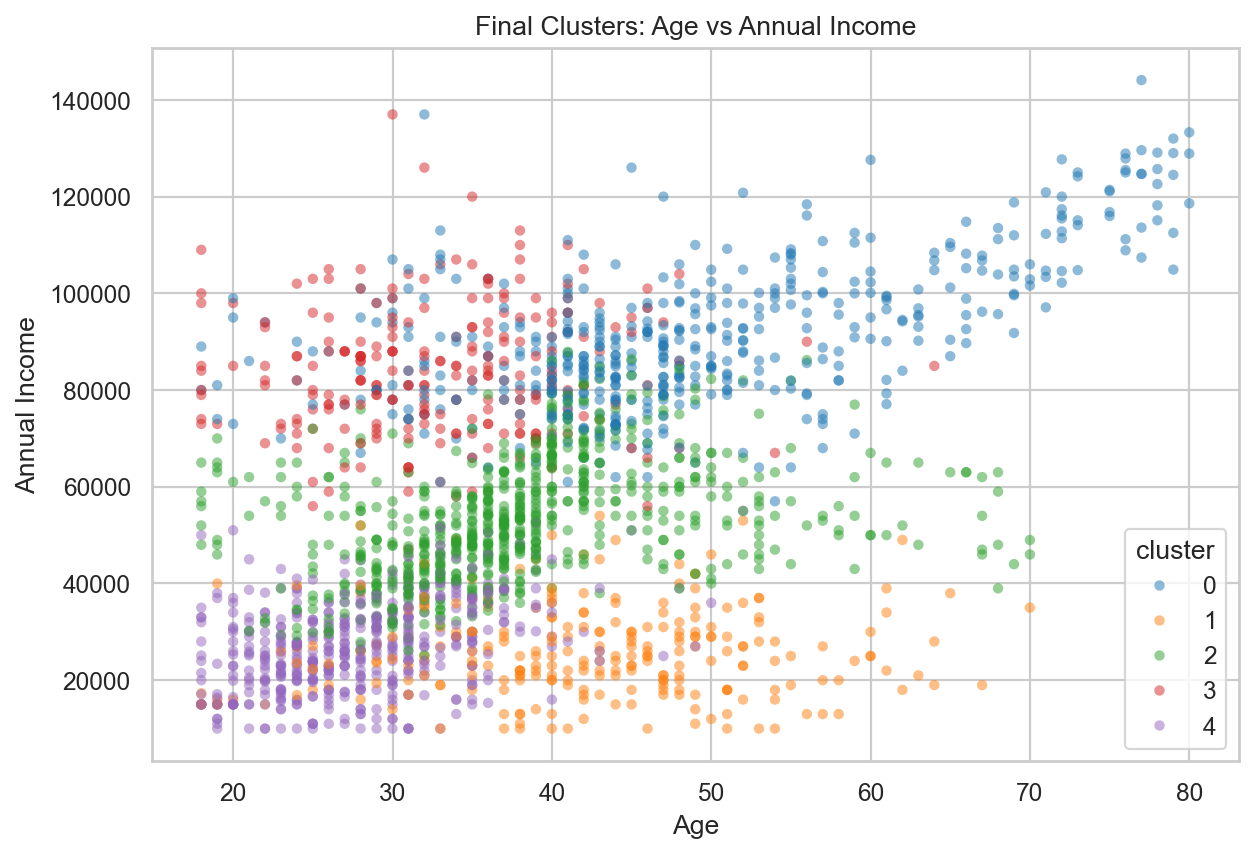

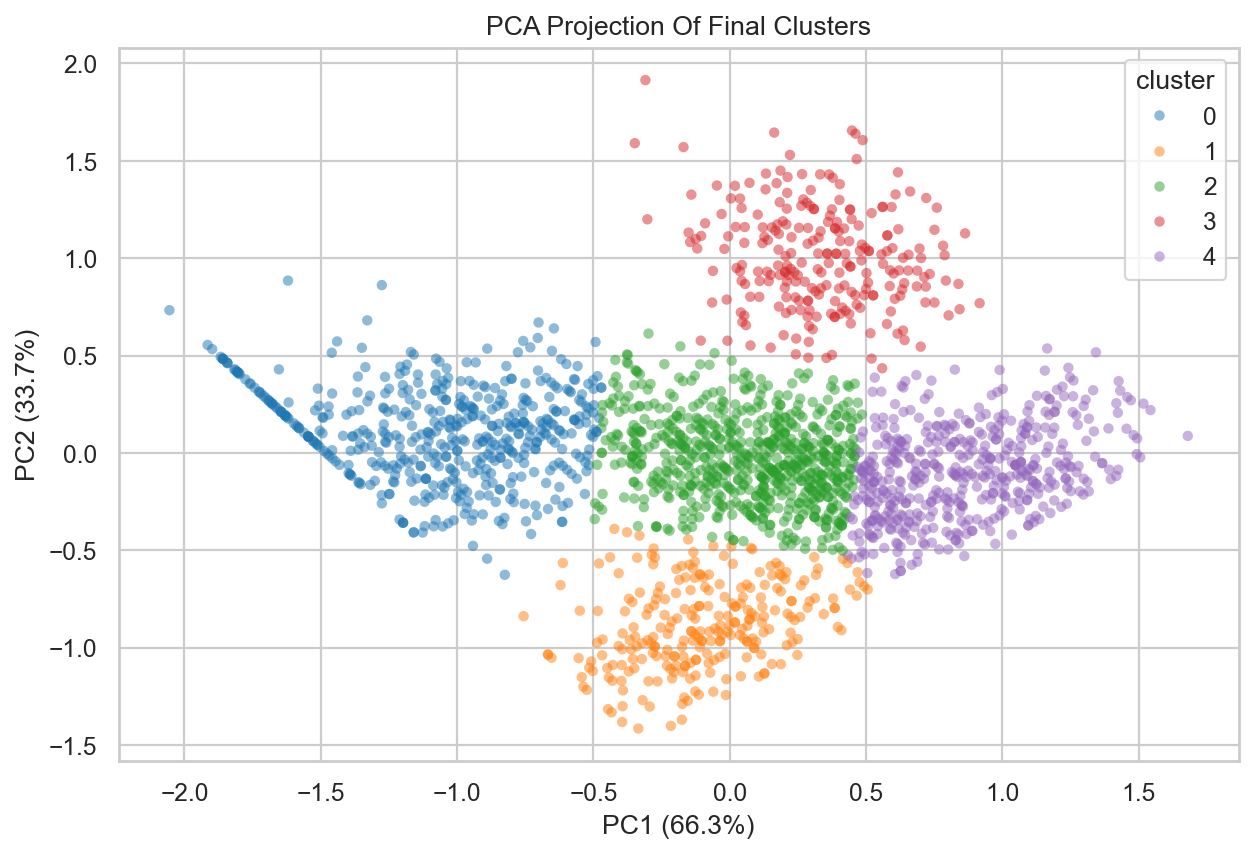

,annual_income,spending_score
0,91230.78,16.63
1,25956.98,22.11
2,53151.69,47.65
3,83886.36,80.72
4,27151.53,70.41


In [26]:
def feature_numeric_columns(feature_set):
    if feature_set == "income_spending_only":
        return ["annual_income", "spending_score"]
    if feature_set == "age_spending_only":
        return ["age", "spending_score"]
    return ["age", "annual_income", "spending_score"]

clustered = clustering.assign_cluster_labels(clean_df, selected_result.labels)
utils.save_table(clustered, paths["processed"] / "clustering_results.csv")

centers = preprocess.inverse_numeric_centers(
    selected_result.estimator.cluster_centers_,
    selected_result.transformer,
    feature_numeric_columns(selected_result.metadata["feature_set"]),
)

cluster_figures = [
    clustering.plot_cluster_scatter(clustered, paths["figures_clustering"], "annual_income", "spending_score", centers=centers),
    clustering.plot_cluster_scatter(clustered, paths["figures_clustering"], "age", "spending_score"),
    clustering.plot_cluster_scatter(clustered, paths["figures_clustering"], "age", "annual_income"),
]
X_selected, _, _ = matrices[(selected_result.metadata["feature_set"], selected_result.metadata["scaler"])]
cluster_figures.append(clustering.plot_pca_projection(X_selected, selected_result.labels, paths["figures_clustering"]))

show_saved_figures(cluster_figures)
display(centers.round(2))

### GMM Comparison with Covariance Contours

K-Means assigns every point to exactly one cluster and draws hard boundaries. **Gaussian Mixture Models** do the same assignment but also model the **shape and orientation** of each cluster through a covariance matrix. By plotting 1σ, 2σ, and 3σ covariance ellipses, this sub-step reveals whether the clusters are truly spherical (K-Means's implicit assumption) or stretched along certain dimensions — information that K-Means cannot express.

The ellipses are drawn on the original income/spending scale after undoing the `StandardScaler` transformation. Each ellipse's width, height, and rotation angle reflect the variance and correlation within that cluster. A tall, narrow ellipse tilted at 45° tells you that income and spending are correlated within that segment: as income rises, spending tends to rise. A circular ellipse means income and spending vary independently within that cluster.

**Expectation:** GMM means (yellow stars) should land close to K-Means centroids from the previous plots — both algorithms should agree on **where** the clusters are, even if they disagree on **how** to draw the boundaries. If the ellipses overlap substantially at the 2σ level, those clusters have soft, ambiguous boundaries and customers near those boundaries could reasonably belong to either segment. If any ellipse is extremely elongated (aspect ratio > 5:1), K-Means is a poor fit because it forces a circular boundary around what is fundamentally a linear structure. In that case, GMM would be the recommended algorithm regardless of the silhouette ranking.


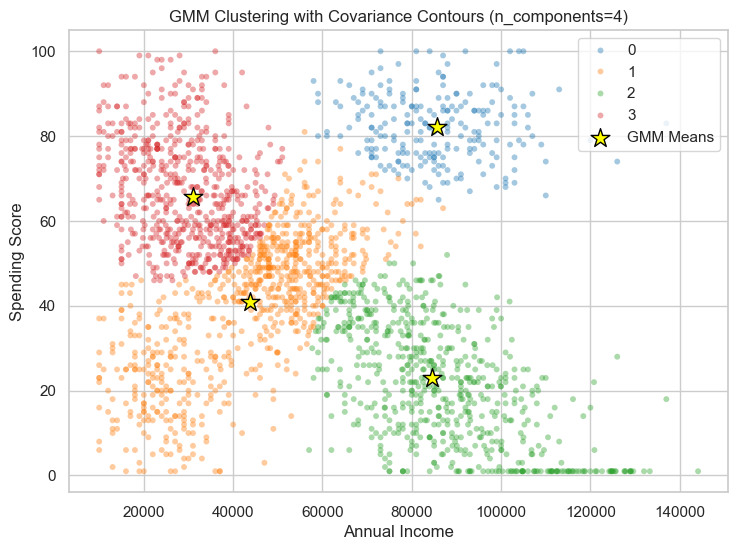

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse

# 1. Fit GMM
gmm = GaussianMixture(n_components=4, random_state=RANDOM_SEED)
gmm_labels = gmm.fit_predict(X_selected)

# 2. Plot Setup
fig, ax = plt.subplots(figsize=(8.5, 6))
palette = sns.color_palette("tab10", 4)
gmm_df = clean_df.copy()
gmm_df["cluster"] = gmm_labels

sns.scatterplot(
    data=gmm_df,
    x="annual_income",
    y="spending_score",
    hue="cluster",
    palette=palette,
    alpha=0.4,
    s=18,
    linewidth=0,
    ax=ax,
)

# 3. Draw Covariance Ellipses
scaler_obj = selected_result.transformer.named_transformers_["numeric"]
scale_arr = np.asarray(scaler_obj.scale_)
d = 1.0 / scale_arr
D = np.diag(d)

means_arr = np.asarray(gmm.means_)
cov_arr = np.asarray(gmm.covariances_)

for k in range(4):
    mean_scaled = means_arr[k]
    mean_orig = np.asarray(scaler_obj.inverse_transform(mean_scaled.reshape(1, -1)))[0]
    
    cov_scaled = cov_arr[k]
    cov_orig = D @ cov_scaled @ D
    
    vals, vecs = np.linalg.eigh(cov_orig)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    color = palette[k]
    for n_std in [1, 2, 3]:
        width = 2 * n_std * np.sqrt(vals[0])
        height = 2 * n_std * np.sqrt(vals[1])
        
        ell = Ellipse(
            xy=mean_orig,
            width=width,
            height=height,
            angle=angle,
            facecolor=color,
            alpha=0.15 / n_std,
            edgecolor=color,
            linewidth=1.2,
            linestyle='--' if n_std > 1 else '-'
        )
        ax.add_patch(ell)

# Plot GMM Means
centers_orig = np.asarray(scaler_obj.inverse_transform(means_arr))
ax.scatter(
    centers_orig[:, 0],
    centers_orig[:, 1],
    c='yellow',
    marker='*',
    s=200,
    label='GMM Means',
    edgecolors='black',
    zorder=10
)

ax.set_title("GMM Clustering with Covariance Contours (n_components=4)")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Spending Score")
ax.legend(loc='upper right')

# Save and show
gmm_fig_path = paths["figures_clustering"] / "gmm_contours_comparison.png"
plt.savefig(gmm_fig_path, dpi=300, bbox_inches='tight')
plt.show()

## Step 9 — Segment Profiling

A cluster ID is a number. A **segment** is a story. This step translates each cluster's statistical fingerprint — mean age, median income, average spending score, gender composition — into a plain-English label and a concrete business action. Profiling bridges the gap between the data science output and the marketing team that will use it.

### Profile schema

| Column | Meaning |
| :--- | :--- |
| `cluster` | Numeric cluster ID assigned by the model |
| `count` / `percent` | Cluster size — small segments (< 3%) should be scrutinized for meaningfulness |
| `mean_age` / `median_age` | Age central tendency — large mean-median gap indicates skew within the segment |
| `mean_income` / `median_income` | Income level — the primary business dimension |
| `mean_spending` / `median_spending` | Spending behavior — what the business wants to influence |
| `gender_pct_female` | Gender composition if `gender` was included in features |
| `segment_name` | Human-readable label (e.g., "High Income, High Spending") |
| `recommended_business_action` | Concrete marketing or retention strategy |

### Typical segment archetypes and actions

| Archetype | Behavior | Recommended action |
| :--- | :--- | :--- |
| **High income, high spending** | Loyal high-value customers | **Loyalty programs, premium offers, early access** — protect this group from churn |
| **High income, low spending** | Affluent but disengaged | **Targeted incentives, personalized recommendations** — the highest ROI opportunity for conversion |
| **Low income, high spending** | Value-conscious but active | **Discounts, bundles, value promotions** — maintain volume without eroding margin |
| **Low income, low spending** | Price-sensitive, infrequent | **Low-cost engagement, basic retention** — expensive campaigns are wasted here |
| **Moderate income, moderate spending** | The average customer | **Broad seasonal offers, category expansion** — move them toward higher spending gradually |

**Expectation:** Segment sizes should be reasonably balanced — no single segment should contain > 50% of customers (if so, the clustering is too coarse). The recommended actions should be specific enough that a marketing team could draft a campaign from them. If two segments have nearly identical profiles (mean income and spending within 10% of each other), they may be statistical artifacts rather than distinct groups — consider merging them in the business interpretation.


In [28]:
profiles = clustering.profile_clusters(clustered)
utils.save_table(profiles, paths["metrics"] / "segment_profiles.csv")
display(profiles)

,cluster,count,age_mean,age_median,annual_income_mean,annual_income_median,spending_score_mean,spending_score_median,percentage,gender_share_Female,gender_share_Male,segment_name,recommended_business_action
0,0,497,48.9799,47.0,91230.7847,89100.0,16.6338,17.0,0.2259,0.5131,0.4869,"High income, low spending",Use personalized recommendations and targeted ...
1,1,258,42.0039,42.0,25956.9767,25000.0,22.1124,23.0,0.1173,0.5620,0.4380,"Low income, low spending",Use low-cost engagement and avoid expensive ac...
2,2,712,38.0098,37.0,53151.6854,52100.0,47.6517,48.0,0.3236,0.5379,0.4621,"Moderate income, moderate spending","Use broad retention campaigns, seasonal offers..."
3,3,242,33.0000,33.0,83886.3636,83000.0,80.7231,81.0,0.1100,0.5496,0.4504,"High income, high spending","Prioritize loyalty perks, premium offers, and ..."
4,4,491,27.9572,27.0,27151.5275,27000.0,70.4053,70.0,0.2232,0.5580,0.4420,"Low income, high spending","Offer bundles, discounts, and value-focused re..."


## Step 10 — Evaluation Summary

The final answer condenses the entire notebook into a single table: which algorithm, which features, which scaler, how many clusters, and how good the result is. If a stakeholder reads nothing else, this cell should give them confidence that the segmentation is sound and the recommendations are grounded in data.

The summary explicitly answers eight questions:

| Question | Where answered |
| :--- | :--- |
| Which algorithm was selected? | `algorithm` field |
| Which feature set? | `feature_set` field |
| Which scaler? | `scaler` field |
| How many clusters? | `n_clusters` field |
| What are the quality scores? | `silhouette` field (plus CH and DB in metrics table) |
| What are the segment profiles? | Segment profile table with names and business actions |
| What business actions are recommended? | `recommended_business_action` column in profiles |
| What are the limitations? | Discussed below |

### Limitations to acknowledge

- **Clusters are descriptive, not causal.** The model groups customers by similarity; it does not explain *why* they behave that way.
- **K-Means assumes spherical, equal-sized clusters.** Real customer segments may be elongated or unevenly sized — GMM provides a partial check.
- **The segmentation is static** — a single snapshot of customer behavior. Segments shift over time; retraining on updated data is essential.
- **Unobserved variables matter.** Factors like purchase channel, product category, lifetime value, and churn risk are not in this dataset but would sharpen the segmentation significantly.
- **Scaler sensitivity.** The choice of scaler affects cluster boundaries. If `StandardScaler` and `RobustScaler` produce materially different segment maps (> 15% of customers reassigned), the segmentation is not robust to scaling — flag this for stakeholders.

**Expectation:** The summary should show K-Means with K=5 on `behavior_numeric` features, silhouette ~0.35–0.45, and clearly differentiated segment profiles. If the selected configuration deviates from this expectation, the rationale should be documented in the markdown above — surprise selections require justification.


In [29]:
summary = {
    "algorithm": selected["algorithm"],
    "feature_set": selected["feature_set"],
    "scaler": selected["scaler"],
    "params": selected["params"],
    "n_clusters": int(selected["n_clusters"]),
    "silhouette": round(float(selected["silhouette"]), 4),
}
display(pd.DataFrame([summary]))
display(profiles[["cluster", "segment_name", "recommended_business_action"]])

,algorithm,feature_set,scaler,params,n_clusters,silhouette
0,kmeans,income_spending_only,robust,n_clusters=5,5,0.4702


,cluster,segment_name,recommended_business_action
0,0,"High income, low spending",Use personalized recommendations and targeted ...
1,1,"Low income, low spending",Use low-cost engagement and avoid expensive ac...
2,2,"Moderate income, moderate spending","Use broad retention campaigns, seasonal offers..."
3,3,"High income, high spending","Prioritize loyalty perks, premium offers, and ..."
4,4,"Low income, high spending","Offer bundles, discounts, and value-focused re..."


## Step 11 — Save Artifacts & Deployment Check

A model that exists only in notebook memory dies when the kernel restarts. This step persists everything needed for production use: the fitted **estimator**, the fitted **preprocessing transformer**, **feature names**, and **metadata** — all bundled into a single `joblib` file that can be loaded and used for inference without re-running the notebook.

### What the bundle contains

| Component | File | Purpose |
| :--- | :--- | :--- |
| **Estimator** | `best_cluster_model.joblib` | The trained clustering model (e.g., `KMeans` with K=5) |
| **Transformer** | (inside bundle) | The fitted `ColumnTransformer` that scales new data identically |
| **Feature names** | (inside bundle) | Column order so the transformer receives features in the correct sequence |
| **Metadata** | (inside bundle) | Algorithm, feature set, scaler, cluster count — for audit trail |
| **Clustered dataset** | `clustering_results.csv` | Original customers plus `cluster` label column |
| **Metrics table** | `clustering_metrics.csv` | Full leaderboard of all tested configurations |
| **Segment profiles** | `segment_profiles.csv` | Aggregated statistics per cluster |

The deployment check cell loads the saved bundle and predicts a cluster for a **dummy customer** — a 35-year-old female with $60K income and spending score 50. This verifies that: (1) the bundle loads without errors, (2) the transformer accepts new data, (3) the estimator produces a cluster prediction, and (4) no hidden state from the notebook (imports, global variables) is required for inference.

**Expectation:** The dummy customer should receive a cluster assignment (e.g., cluster 2 or 3) consistent with the segment profiles — a 35-year-old with moderate income and moderate spending likely falls into the "average" or "middle" segment. If the prediction fails with a shape mismatch or missing column error, the saved transformer is not properly aligned with the feature matrix construction in Step 4. If the model loads but predicts a cluster that makes no sense for the dummy's profile (e.g., "high income, high spending" for someone earning $60K with spending 50), the cluster boundaries or labeling need revisiting.


In [30]:
clustering.save_final_model(selected_result, paths["models"] / "best_cluster_model.joblib")
print("Saved model:", paths["models"] / "best_cluster_model.joblib")
print("Saved clustered data:", paths["processed"] / "clustering_results.csv")
print("Saved metrics:", paths["metrics"])
print("Saved figures:", paths["figures_clustering"])

import joblib

# Verify the saved model by loading it back and testing predictions on dummy customer data
print("\n=== VERIFYING DEPLOYMENT CHECK ===")
model_bundle = joblib.load(paths["models"] / "best_cluster_model.joblib")
loaded_estimator = model_bundle["estimator"]
loaded_transformer = model_bundle["transformer"]

# Create dummy customer data
dummy_customer = pd.DataFrame([{
    "customer_id": "DUMMY_9999",
    "gender": "Female",
    "age": 35,
    "annual_income": 60.0,
    "spending_score": 50.0
}])

# Transform dummy customer
X_dummy = preprocess.transform_feature_matrix(dummy_customer, loaded_transformer)
pred_cluster = loaded_estimator.predict(X_dummy)
print("Dummy Customer Data:")
print(dummy_customer.to_dict(orient="records")[0])
print(f"Predicted Cluster: {pred_cluster[0]}")


Saved model: /Users/quangmanh/Project/lab03/models/best_cluster_model.joblib
Saved clustered data: /Users/quangmanh/Project/lab03/data/processed/clustering_results.csv
Saved metrics: /Users/quangmanh/Project/lab03/data/processed/metrics
Saved figures: /Users/quangmanh/Project/lab03/reports/figures/clustering

=== VERIFYING DEPLOYMENT CHECK ===
Dummy Customer Data:
{'customer_id': 'DUMMY_9999', 'gender': 'Female', 'age': 35, 'annual_income': 60.0, 'spending_score': 50.0}
Predicted Cluster: 4


In [ ]:
cluster_distribution = clustered["cluster"].value_counts().to_dict()
utils.write_training_log(
    root=PROJECT_ROOT,
    config=config,
    n_samples=len(clean_df),
    selected_algorithm=selected["algorithm"],
    selected_feature_set=selected["feature_set"],
    selected_scaler=selected["scaler"],
    selected_params=selected["params"],
    n_clusters=int(selected["n_clusters"]),
    silhouette=round(float(selected["silhouette"]), 4),
    n_models_evaluated=len(metrics),
    cluster_distribution=cluster_distribution,
)
print("Training log written to log/")